# PRCP-1023: Forecasting COVID-19 Cases and Deaths from the Johns Hopkins Data

**Domain:** Healthcare

### Problem statement
The project brief has three tasks:
1. Prepare a complete data analysis report on the supplied data.
2. Fix a prediction period and build a model that forecasts COVID-19 confirmed cases/deaths for a specific country or region from its past values.
3. Make preparation suggestions to that country's health department based on the predictions.

It also asks for a model comparison report with a recommended production model, and a report on the challenges faced with the data and the techniques used to deal with them.

### What this notebook does
I inspected the supplied files before deciding anything, built country-level daily series, screened every country for data quality and chose the US, analysed its cases and deaths, and set up a 14-day forecasting problem with chronological validation. I then compared seven forecasting approaches (two baselines, ETS, SARIMA, Ridge, Gradient Boosting and an average of the best three), tested them on a 28-day holdout, produced a forecast for 22 Sep to 5 Oct 2020 and turned it into preparation considerations.

### Structure
1. Setup
2. Dataset discovery
3. Building country-level series
4. Choosing the country
5. Exploratory analysis of the US series
6. Forecasting problem: target, horizon and validation design
7. Model development and validation
8. Holdout test
9. Model comparison report and production model
10. Production forecast (22 Sep to 5 Oct 2020)
11. Preparation suggestions for the health department
12. Challenges report
13. Conclusions and limitations

The data was read from the three CSV files in the project zip, unzipped into a local `dataset` folder; the path is set in the setup cell.

## 1. Setup
All imports are in one place. The cell also prints the library versions, because pandas 3 and statsmodels 0.15 changed some defaults and anyone re-running the notebook should know which versions produced these results.

In [1]:
import os
import glob
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

for lib in [np, pd, matplotlib, sns, sklearn, statsmodels]:
    print(f"{lib.__name__:<12} {lib.__version__}")


# folder holding the unzipped JHU files, relative to the notebook
DATA_DIR = r"C:\Users\sahup\Downloads\covid-19\dataset"
print(os.path.abspath(DATA_DIR), "| exists:", os.path.isdir(DATA_DIR))

numpy        2.5.3
pandas       3.0.2
matplotlib   3.11.1
seaborn      0.13.2
sklearn      1.9.1
statsmodels  0.15.0
C:\Users\sahup\Downloads\covid-19\dataset | exists: True


## 2. Dataset discovery
The project description mentions RAW and CONVENIENT files, US county data and a metadata file, so before assuming any of that I listed what was actually in the zip. I printed the first raw lines of each CSV before letting pandas parse them, because a file with more than one header row would otherwise be read wrongly without any error.

In [2]:
all_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True))
all_files = [f for f in all_files if os.path.isfile(f)]

inventory = pd.DataFrame({
    "file": [os.path.relpath(f, DATA_DIR) for f in all_files],
    "extension": [os.path.splitext(f)[1].lower() for f in all_files],
    "size_mb": [round(os.path.getsize(f) / 1e6, 2) for f in all_files],
})
inventory

,file,extension,size_mb
0,time_series_covid19_confirmed_global.csv,.csv,0.27
1,time_series_covid19_deaths_global.csv,.csv,0.19
2,time_series_covid19_recovered_global.csv,.csv,0.24


In [3]:
csv_files = [f for f in all_files if f.lower().endswith(".csv")]

# raw text of the first lines, before pandas decides what the header is
for path in csv_files:
    print("=" * 100)
    print(os.path.relpath(path, DATA_DIR))
    with open(path, encoding="utf-8", errors="replace") as fh:
        for i in range(4):
            line = fh.readline()
            if not line:
                break
            text = line.rstrip()
            print(f"  line {i}: {text[:250]}{' ...' if len(text) > 250 else ''}")

time_series_covid19_confirmed_global.csv
  line 0: Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,2/2/20,2/3/20,2/4/20,2/5/20,2/6/20,2/7/20,2/8/20,2/9/20,2/10/20,2/11/20,2/12/20,2/13/20,2/14/20,2/15/20,2/16/20,2/17/20,2/18 ...
  line 1: ,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,4,4,5,7,7,7,11,16,21,22,22,22,24,24,40,40,74,84,94,110,110,120,170,174,237,273,281,299,349,367,423,444,484,521,555,607,665,714 ...
  line 2: ,Albania,41.1533,20.1683,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,10,12,23,33,38,42,51,55,59,64,70,76,89,104,123,146,174,186,197,212,223,243,259,277,304,333,361,377,383,400,409,416,433,446,467,47 ...
  line 3: ,Algeria,28.0339,1.6596,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,3,5,12,12,17,17,19,20,20,20,24,26,37,48,54,60,74,8

In [4]:
frames = {}
for path in csv_files:
    name = os.path.relpath(path, DATA_DIR)
    frames[name] = pd.read_csv(path, low_memory=False)

summary = pd.DataFrame([
    {
        "file": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "dtype_mix": dict(df.dtypes.astype(str).value_counts()),
    }
    for name, df in frames.items()
])
summary

,file,rows,columns,dtype_mix
0,time_series_covid19_confirmed_global.csv,266,248,"{'int64': 244, 'str': 2, 'float64': 2}"
1,time_series_covid19_deaths_global.csv,266,248,"{'int64': 244, 'str': 2, 'float64': 2}"
2,time_series_covid19_recovered_global.csv,253,248,"{'int64': 244, 'str': 2, 'float64': 2}"


In [5]:
# first and last columns: wide files with dates as columns show their date range at the end
for name, df in frames.items():
    print("=" * 100)
    print(name, df.shape)
    cols = list(df.columns)
    print("first columns:", cols[:8])
    if len(cols) > 8:
        print("last columns: ", cols[-4:])
    display(df.iloc[:5, :8])

time_series_covid19_confirmed_global.csv (266, 248)
first columns: ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20']
last columns:  ['9/18/20', '9/19/20', '9/20/20', '9/21/20']


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0
1,NaN,Albania,41.15330,20.168300,0,0,0,0
2,NaN,Algeria,28.03390,1.659600,0,0,0,0
3,NaN,Andorra,42.50630,1.521800,0,0,0,0
4,NaN,Angola,-11.20270,17.873900,0,0,0,0


time_series_covid19_deaths_global.csv (266, 248)
first columns: ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20']
last columns:  ['9/18/20', '9/19/20', '9/20/20', '9/21/20']


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0
1,NaN,Albania,41.15330,20.168300,0,0,0,0
2,NaN,Algeria,28.03390,1.659600,0,0,0,0
3,NaN,Andorra,42.50630,1.521800,0,0,0,0
4,NaN,Angola,-11.20270,17.873900,0,0,0,0


time_series_covid19_recovered_global.csv (253, 248)
first columns: ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20']
last columns:  ['9/18/20', '9/19/20', '9/20/20', '9/21/20']


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0
1,NaN,Albania,41.15330,20.168300,0,0,0,0
2,NaN,Algeria,28.03390,1.659600,0,0,0,0
3,NaN,Andorra,42.50630,1.521800,0,0,0,0
4,NaN,Angola,-11.20270,17.873900,0,0,0,0


**What the files contain**

Observation: the zip has only three files, all in the original JHU global layout: confirmed cases, deaths and recovered. There is no CONVENIENT version, no US county data and no separate metadata file, so the supplied data is narrower than the description. Each file is wide: four metadata columns (Province/State, Country/Region, Lat, Long) followed by one column per date, 244 date columns from 1/22/20 to 9/21/20. Confirmed and deaths have 266 rows and recovered has 253.

Interpretation: the raw lines show values that only grow (Afghanistan's confirmed count goes 0, 1, ..., 4, 5, 7, 11), so these are cumulative totals and any daily series has to be derived by differencing. The recovered file already shows a fall for Algeria (65, 65, 24, 65), so the cumulative series are not perfectly clean.

Limitation: the row counts differ between files, so the three files cannot simply be joined row by row.

### 2.1 Dates, geography and data quality
Next I checked whether the date columns are continuous and identical across files, how the geography is structured, whether the files line up, how cumulative the values really are, and whether any rows are not real countries.

In [6]:
print("pandas", pd.__version__)
meta_cols = ["Province/State", "Country/Region", "Lat", "Long"]

date_info = []
for name, df in frames.items():
    date_cols = [c for c in df.columns if c not in meta_cols]
    dates = pd.to_datetime(date_cols, format="%m/%d/%y")
    gaps = pd.Series(dates).diff().dropna().dt.days
    date_info.append({
        "file": name,
        "n_dates": len(dates),
        "first": dates.min().date(),
        "last": dates.max().date(),
        "sorted": dates.is_monotonic_increasing,
        "unique": dates.is_unique,
        "gap_days": sorted(gaps.unique().tolist()),
    })
display(pd.DataFrame(date_info))

# one distinct tuple means all three files share exactly the same date columns
date_sets = {tuple(c for c in df.columns if c not in meta_cols) for df in frames.values()}
print("distinct date-column sets across files:", len(date_sets))

pandas 3.0.2


,file,n_dates,first,last,sorted,unique,gap_days
0,time_series_covid19_confirmed_global.csv,244,2020-01-22,2020-09-21,True,True,[1]
1,time_series_covid19_deaths_global.csv,244,2020-01-22,2020-09-21,True,True,[1]
2,time_series_covid19_recovered_global.csv,244,2020-01-22,2020-09-21,True,True,[1]


distinct date-column sets across files: 1


In [7]:
for name, df in frames.items():
    has_province = df["Province/State"].notna()
    print(name)
    print("  rows:", len(df),
          "| unique countries:", df["Country/Region"].nunique(),
          "| rows with a province:", int(has_province.sum()),
          "| countries split into provinces:", df.loc[has_province, "Country/Region"].nunique())
    print("  duplicate (province, country) keys:",
          int(df.duplicated(subset=["Province/State", "Country/Region"]).sum()))
    print("  missing values in metadata:", df[meta_cols].isna().sum().to_dict())
    print("  missing values in date columns:", int(df.drop(columns=meta_cols).isna().sum().sum()))
    print()

conf = frames["time_series_covid19_confirmed_global.csv"]
deaths = frames["time_series_covid19_deaths_global.csv"]
rec = frames["time_series_covid19_recovered_global.csv"]

# countries reported at province level in the confirmed file
conf[conf["Province/State"].notna()].groupby("Country/Region").size().sort_values(ascending=False)

time_series_covid19_confirmed_global.csv
  rows: 266 | unique countries: 188 | rows with a province: 81 | countries split into provinces: 7
  duplicate (province, country) keys: 0
  missing values in metadata: {'Province/State': 185, 'Country/Region': 0, 'Lat': 0, 'Long': 0}
  missing values in date columns: 0

time_series_covid19_deaths_global.csv
  rows: 266 | unique countries: 188 | rows with a province: 81 | countries split into provinces: 7
  duplicate (province, country) keys: 0
  missing values in metadata: {'Province/State': 185, 'Country/Region': 0, 'Lat': 0, 'Long': 0}
  missing values in date columns: 0

time_series_covid19_recovered_global.csv
  rows: 253 | unique countries: 188 | rows with a province: 67 | countries split into provinces: 6
  duplicate (province, country) keys: 0
  missing values in metadata: {'Province/State': 186, 'Country/Region': 0, 'Lat': 0, 'Long': 0}
  missing values in date columns: 0



Country/Region
China             33
Canada            14
France            10
United Kingdom    10
Australia          8
Netherlands        4
Denmark            2
dtype: int64

In [8]:
def row_keys(df):
    return set(zip(df["Province/State"].fillna(""), df["Country/Region"]))

k_conf, k_deaths, k_rec = row_keys(conf), row_keys(deaths), row_keys(rec)

print("confirmed and deaths have identical rows:", k_conf == k_deaths)
print("\nin confirmed but not in recovered:")
print(sorted(k_conf - k_rec))
print("\nin recovered but not in confirmed:")
print(sorted(k_rec - k_conf))

confirmed and deaths have identical rows: True

in confirmed but not in recovered:
[('Alberta', 'Canada'), ('British Columbia', 'Canada'), ('Diamond Princess', 'Canada'), ('Grand Princess', 'Canada'), ('Manitoba', 'Canada'), ('New Brunswick', 'Canada'), ('Newfoundland and Labrador', 'Canada'), ('Northwest Territories', 'Canada'), ('Nova Scotia', 'Canada'), ('Ontario', 'Canada'), ('Prince Edward Island', 'Canada'), ('Quebec', 'Canada'), ('Saskatchewan', 'Canada'), ('Yukon', 'Canada')]

in recovered but not in confirmed:
[('', 'Canada')]


In [9]:
for name, df in frames.items():
    values = df.drop(columns=meta_cols).copy()
    row_diff = values.diff(axis=1).iloc[:, 1:]
    country_diff = values.groupby(df["Country/Region"]).sum().diff(axis=1).iloc[:, 1:]
    country_stacked = country_diff.stack()

    print(name)
    print("  row level: negative day-to-day changes:", int((row_diff < 0).sum().sum()),
          "spread over", int((row_diff < 0).any(axis=1).sum()), "of", len(df), "rows")
    print("  country level: negative changes:", int((country_diff < 0).sum().sum()),
          "spread over", int((country_diff < 0).any(axis=1).sum()), "of", len(country_diff), "countries")
    print("  most negative country-level change:", country_stacked.min(),
          "at", country_stacked.idxmin())
    print()

time_series_covid19_confirmed_global.csv
  row level: negative day-to-day changes: 113 spread over 51 of 266 rows
  country level: negative changes: 45 spread over 31 of 188 countries
  most negative country-level change: -10034 at ('Spain', '4/24/20')

time_series_covid19_deaths_global.csv
  row level: negative day-to-day changes: 79 spread over 40 of 266 rows
  country level: negative changes: 55 spread over 34 of 188 countries
  most negative country-level change: -1918 at ('Spain', '5/25/20')

time_series_covid19_recovered_global.csv
  row level: negative day-to-day changes: 154 spread over 76 of 253 rows
  country level: negative changes: 93 spread over 59 of 188 countries
  most negative country-level change: -16298 at ('Mexico', '7/19/20')



In [10]:
# missing or (0, 0) coordinates usually flag cruise ships or placeholder rows
odd_rows = conf[conf["Lat"].isna() | ((conf["Lat"] == 0) & (conf["Long"] == 0))]
odd_rows[meta_cols + [conf.columns[-1]]]

,Province/State,Country/Region,Lat,Long,9/21/20
41,Diamond Princess,Canada,0.0,0.0,0
42,Grand Princess,Canada,0.0,0.0,13
102,NaN,Diamond Princess,0.0,0.0,712
168,NaN,MS Zaandam,0.0,0.0,9


**Data quality findings**

Dates: all three files cover the same 244 consecutive days, 22 Jan 2020 to 21 Sep 2020, with no gaps and no repeated dates. A one-day lag therefore always means one calendar day.

Missing values and duplicates: there are no missing values in any date column and no duplicate (province, country) keys. The only missing values are empty Province/State cells (185 in confirmed and deaths, 186 in recovered), which mean the row covers the whole country. No imputation was needed.

Geography: 188 country names appear, and 7 countries are split into provinces (China 33 rows, Canada 14, France and the United Kingdom 10 each, Australia 8, Netherlands 4, Denmark 2). Confirmed and deaths have identical rows, but recovered does not: Canada is reported by province in confirmed and deaths and as one national row in recovered. Aggregating to country level removes this mismatch.

Non-country rows: Diamond Princess and MS Zaandam appear as countries, and Diamond Princess and Grand Princess also appear as Canadian provinces, all with coordinates (0, 0). These are cruise ships, not populations, so I excluded them.

Corrections in the cumulative data: at country level, 31 countries have at least one fall in cumulative confirmed cases and 34 in cumulative deaths. The largest are in Spain: −10,034 cases on 24 Apr and −1,918 deaths on 25 May. A cumulative count cannot genuinely fall, so these are reporting revisions. Recovered is worse (59 countries with falls, the largest −16,298 for Mexico on 19 Jul).

Interpretation: confirmed and deaths are usable once aggregated to country level, but the choice of country has to take revisions into account. I left recovered out of the modelling: the tasks ask for cases and deaths, and recovered has both the most revisions and the inconsistent Canada reporting.

Limitation: these checks only find revisions that show up as falls. A backlog added on a single day would not show up here, which is why the country screening below also looks at spikes.

## 3. Building country-level series
Provinces were summed to country level and the cruise ship rows removed. Daily new cases and deaths were then derived as the day-to-day change in the cumulative totals. The first day (22 Jan) keeps its cumulative value because it holds everything reported up to that date; it lies outside the modelling period anyway. Two checks confirm nothing was lost: country totals match the raw rows on the last date, and the daily values add back up to the final cumulative totals.

In [11]:
ship_names = ["Diamond Princess", "MS Zaandam", "Grand Princess"]

def country_cumulative(df):
    is_ship = df["Country/Region"].isin(ship_names) | df["Province/State"].isin(ship_names)
    wide = (df.loc[~is_ship]
              .drop(columns=["Province/State", "Lat", "Long"])
              .groupby("Country/Region")
              .sum())
    wide.columns = pd.to_datetime(wide.columns, format="%m/%d/%y")
    out = wide.T
    out.index.name = "date"
    return out

cum_cases = country_cumulative(conf)
cum_deaths = country_cumulative(deaths)
print("cumulative cases :", cum_cases.shape)
print("cumulative deaths:", cum_deaths.shape)

# country totals reconcile with the raw rows once ship rows are removed
for raw, table in [(conf, cum_cases), (deaths, cum_deaths)]:
    is_ship = raw["Country/Region"].isin(ship_names) | raw["Province/State"].isin(ship_names)
    print("last-day totals match:", raw.loc[~is_ship, raw.columns[-1]].sum() == table.iloc[-1].sum())

cumulative cases : (244, 186)
cumulative deaths: (244, 186)
last-day totals match: True
last-day totals match: True


In [12]:
daily_cases = cum_cases.diff()
daily_deaths = cum_deaths.diff()

# 22 Jan carries everything reported up to that date
daily_cases.iloc[0] = cum_cases.iloc[0]
daily_deaths.iloc[0] = cum_deaths.iloc[0]

# summed daily changes give back the final cumulative totals
print("cases reconcile :", (daily_cases.sum() == cum_cases.iloc[-1]).all())
print("deaths reconcile:", (daily_deaths.sum() == cum_deaths.iloc[-1]).all())

cases reconcile : True
deaths reconcile: True


Both checks passed. 186 country series remain for cases and deaths, the last-day totals match the raw files, and the daily series reconcile exactly with the cumulative totals.

## 4. Choosing the country
I didn't want to pick a country just because it is common in COVID examples, so I screened all 186 against criteria that matter for forecasting:
- enough history;
- no revisions (negative daily values);
- no reporting gaps (zero-case or zero-death days during an active outbreak);
- no batch dumps, measured as the largest ratio of a single day to its centred 7-day mean;
- enough daily volume that counts are not dominated by noise.

Zero shares and spike ratios use the last 120 days, the period that matters most for training and testing. The table shows the 20 countries with the most cases, and the chart shows the shape of the eight largest outbreaks.

In [13]:
# last 120 days screen how active and how clean each series is in its most recent phase
recent_window = 120
rows = []
for country in cum_cases.columns:
    started = cum_cases[country][cum_cases[country] > 0]
    if started.empty:
        continue
    recent_c = daily_cases[country].iloc[-recent_window:]
    recent_d = daily_deaths[country].iloc[-recent_window:]
    weekly_mean = recent_c.rolling(7, center=True).mean().replace(0, np.nan)
    rows.append({
        "country": country,
        "first_case": started.index[0].date(),
        "days_with_cases": len(started),
        "total_cases": int(cum_cases[country].iloc[-1]),
        "total_deaths": int(cum_deaths[country].iloc[-1]),
        "neg_case_days": int((daily_cases[country] < 0).sum()),
        "neg_death_days": int((daily_deaths[country] < 0).sum()),
        "zero_case_share_recent": round((recent_c == 0).mean(), 3),
        "zero_death_share_recent": round((recent_d == 0).mean(), 3),
        "mean_daily_cases_recent": round(recent_c.mean(), 1),
        "mean_daily_deaths_recent": round(recent_d.mean(), 1),
        "max_spike_ratio_recent": round((recent_c / weekly_mean).max(), 2),
    })

candidates = pd.DataFrame(rows).set_index("country")
print("countries screened:", len(candidates))
candidates.sort_values("total_cases", ascending=False).head(20)

countries screened: 186


,first_case,days_with_cases,total_cases,total_deaths,neg_case_days,neg_death_days,zero_case_share_recent,zero_death_share_recent,mean_daily_cases_recent,mean_daily_deaths_recent,max_spike_ratio_recent
country,,,,,,,,,,,
US,2020-01-22,244,6856884,199865,0,0,0.000,0.000,43380.0,824.7,1.32
India,2020-01-30,236,5487580,87882,0,1,0.008,0.008,44575.4,698.8,1.20
Brazil,2020-02-26,209,4558040,137272,0,0,0.000,0.000,34956.9,955.0,1.76
Russia,2020-01-31,235,1105048,19420,0,0,0.000,0.000,6338.1,132.3,1.06
Colombia,2020-03-06,200,770435,24397,1,1,0.000,0.008,6243.8,197.2,2.12
Peru,2020-03-06,200,768895,31369,0,0,0.075,0.083,5407.8,232.6,3.25
Mexico,2020-02-28,207,700580,73697,0,0,0.000,0.000,5266.3,552.5,1.42
Spain,2020-02-01,234,671468,30663,2,2,0.208,0.317,3630.8,15.9,3.11
South Africa,2020-03-05,201,661936,15992,0,0,0.000,0.000,5327.9,129.7,1.67


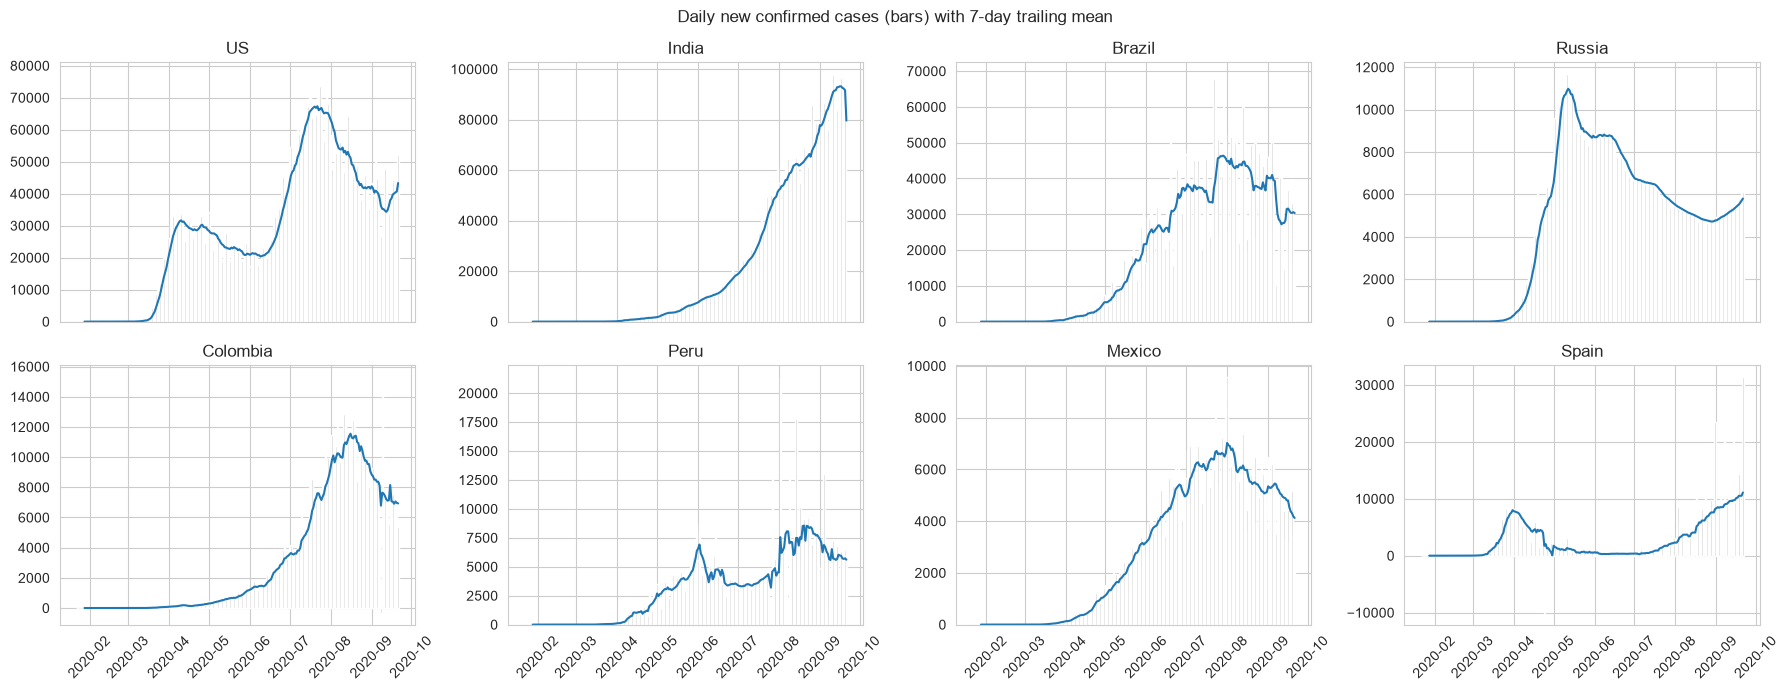

In [14]:
top_countries = candidates.sort_values("total_cases", ascending=False).head(8).index
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for ax, country in zip(axes.ravel(), top_countries):
    ax.bar(daily_cases.index, daily_cases[country], color="lightgray", width=1)
    ax.plot(daily_cases[country].rolling(7).mean(), color="tab:blue")
    ax.set_title(country)
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Daily new confirmed cases (bars) with 7-day trailing mean")
plt.tight_layout()
plt.show()

**Screening results**

Observation: Spain, France and Peru show clear reporting problems. In the last 120 days Spain reported zero cases on 20.8% of days and zero deaths on 31.7%, France 17.5% and 25.8%, and Peru 7.5% and 8.3%. Their spike ratios are 3.11, 4.17 and 3.25, meaning single days three to four times the weekly average, and Spain's chart even has negative bars. Colombia has one negative day for each target and a spike ratio of 2.12. The US, India, Brazil, Russia and Mexico have no or almost no negative or zero days and spike ratios below 1.8.

Interpretation: for countries like Spain and France a model would mostly learn the reporting schedule (skipped days followed by catch-up days) rather than the course of the outbreak. The five clean countries go to a closer check. The charts also show different shapes: the US had two waves and an upturn at the end, India was in one long growth phase, Brazil's daily bars show a visible weekly oscillation, and Russia and Mexico are mostly in a single decline.

Limitation: the screening uses summary measures, so the exact location of the remaining anomalies is checked next.

The cells below locate every zero and negative day after each shortlisted country passed 100 cumulative cases, then show the last two weeks for the two strongest candidates.

In [15]:
shortlist = ["US", "India", "Brazil", "Russia", "Mexico"]

# "active" starts once a country passes 100 cumulative cases, so early genuine zeros are ignored
for country in shortlist:
    active = cum_cases[country] >= 100
    c = daily_cases.loc[active, country]
    d = daily_deaths.loc[active, country]
    print(f"{country} | active from {c.index[0].date()} ({len(c)} days)")
    print("  zero-case days      :", [x.date() for x in c.index[c == 0]])
    print("  negative-case days  :", [x.date() for x in c.index[c < 0]])
    print("  zero-death days (last 120):", [x.date() for x in d.iloc[-recent_window:].index[d.iloc[-recent_window:] == 0]])
    print("  negative-death days :", [x.date() for x in d.index[d < 0]])
    print()

US | active from 2020-03-04 (202 days)
  zero-case days      : []
  negative-case days  : []
  zero-death days (last 120): []
  negative-death days : []

India | active from 2020-03-14 (192 days)
  zero-case days      : [datetime.date(2020, 9, 21)]
  negative-case days  : []
  zero-death days (last 120): [datetime.date(2020, 9, 21)]
  negative-death days : [datetime.date(2020, 3, 21)]

Brazil | active from 2020-03-13 (193 days)
  zero-case days      : [datetime.date(2020, 3, 14)]
  negative-case days  : []
  zero-death days (last 120): []
  negative-death days : []

Russia | active from 2020-03-17 (189 days)
  zero-case days      : []
  negative-case days  : []
  zero-death days (last 120): []
  negative-death days : []

Mexico | active from 2020-03-18 (188 days)
  zero-case days      : []
  negative-case days  : []
  zero-death days (last 120): []
  negative-death days : []



In [17]:
pd.DataFrame({
    "US_cases": daily_cases["US"],
    "India_cases": daily_cases["India"],
    "US_deaths": daily_deaths["US"],
    "India_deaths": daily_deaths["India"],
}).tail(14).astype(int)

,US_cases,India_cases,US_deaths,India_deaths
date,,,,
2020-09-08,26387,89706,445,1115
2020-09-09,33203,95735,1206,1172
2020-09-10,35888,96551,907,1209
2020-09-11,47552,97570,1213,1201
2020-09-12,41471,94372,714,1114
2020-09-13,34999,92071,378,1136
2020-09-14,33530,83809,422,1054
2020-09-15,38690,90123,1288,1290
2020-09-16,37709,97894,982,1132


**Decision: the United States**

Observation: the US has no zero or negative days for cases or deaths in its whole active period (202 days from 4 Mar). India's only zero-case and zero-death day is 21 Sep, the last date in the file, right after days of 86,961 to 97,894 cases and over 1,100 deaths. Brazil's single zero is on 14 Mar, early in its outbreak.

Interpretation: India's zero is not a real zero. Its cumulative total simply hadn't been updated for the last date when this snapshot was taken. Dropping the last day would fix it, but the US needs no correction at all. I chose the US because:
1. it is the only candidate with no anomalies in either target over its full active period;
2. it has the longest active history (202 days);
3. it went through several phases (first wave, decline, a larger second wave, decline and an upturn), so validation tests the models on changing behaviour rather than one smooth curve;
4. its volumes (about 43,000 cases and 825 deaths per day over the last 120 days) are large enough to model both targets without small-count noise.

India was the runner-up. With its last day dropped it is also clean, but it is essentially one growth phase, and its test period would have sat on a possible turning point with a model trained only on growth.

Limitation: the US figures are a national total, which hides very different situations across states. The forecast describes the country as a whole.

## 5. Exploratory analysis of the US series
Each analysis in this section answers a question that affects the modelling: the overall shape of the outbreak, whether there is a weekly reporting cycle, how much the series depends on its own past, whether it is stationary, and how deaths relate to cases. The active period starts on the first day with at least 100 cumulative cases.

In [18]:
country = "US"
us = pd.DataFrame({
    "cum_cases": cum_cases[country],
    "cum_deaths": cum_deaths[country],
    "daily_cases": daily_cases[country],
    "daily_deaths": daily_deaths[country],
}).astype(int)
us["weekday"] = us.index.day_name()

active_start = us.index[us["cum_cases"] >= 100][0]
print("active from", active_start.date(), "| active days:", int((us.index >= active_start).sum()))
us.loc[active_start:, ["daily_cases", "daily_deaths"]].describe().round(1)

active from 2020-03-04 | active days: 202


,daily_cases,daily_deaths
count,202.0,202.0
mean,33944.6,989.4
std,18175.3,643.7
min,31.0,1.0
25%,22467.5,511.8
50%,31346.5,946.5
75%,46108.5,1328.0
max,77255.0,2609.0


The active period starts on 4 Mar 2020 and covers 202 days. Over that period daily cases averaged 33,945 (median 31,347, maximum 77,255) and daily deaths averaged 989 (median 947, maximum 2,609). The minimums (31 cases, 1 death) come from early March, which is one reason later steps start from April.

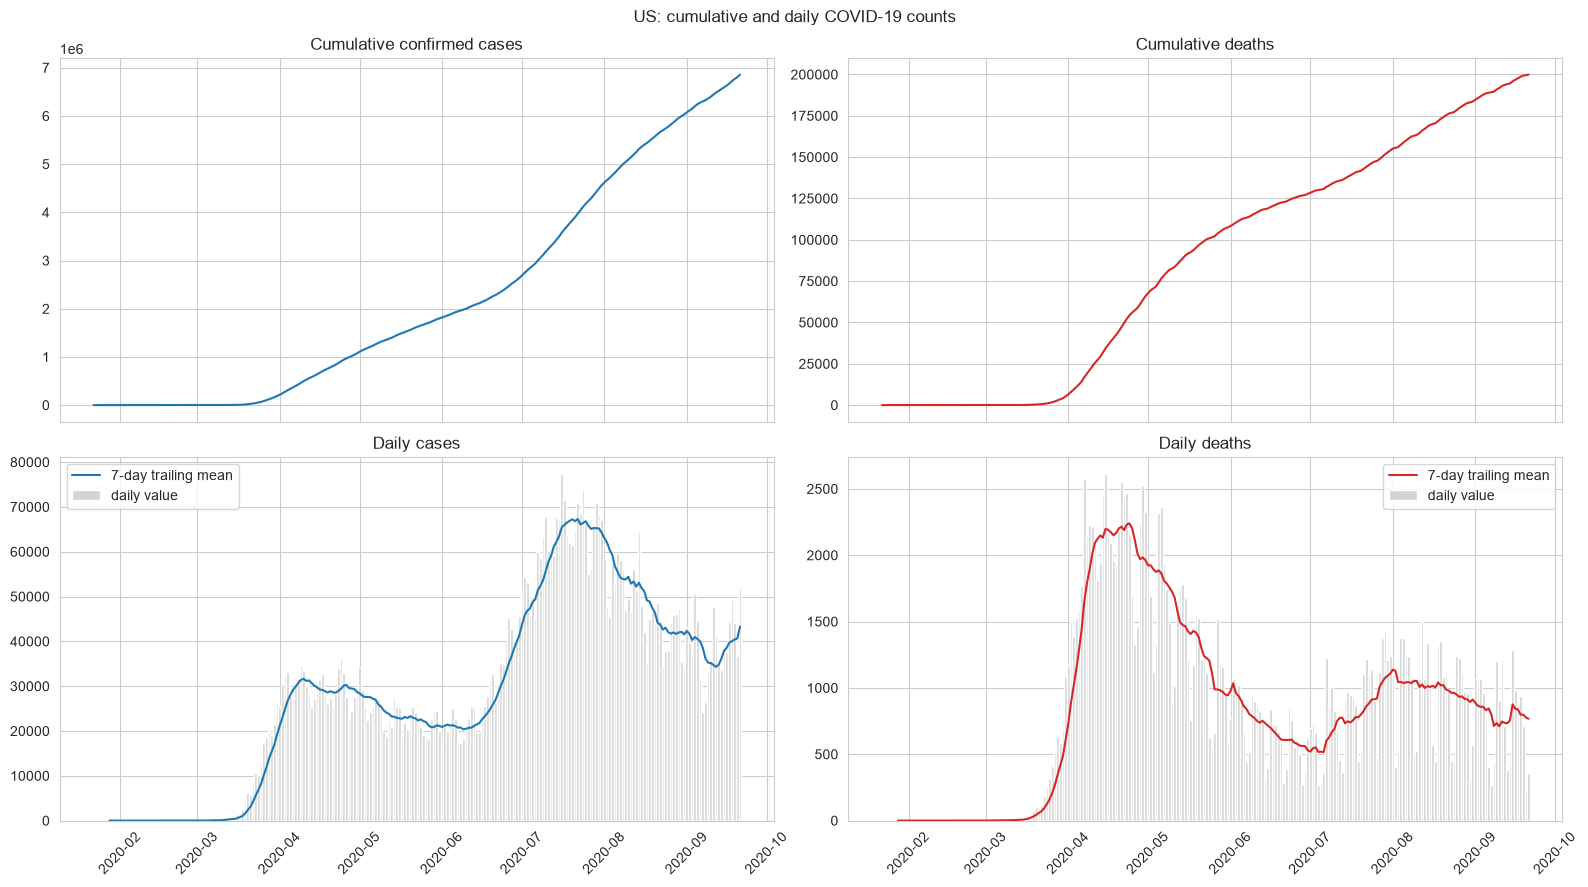

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
axes[0, 0].plot(us["cum_cases"], color="tab:blue")
axes[0, 0].set_title("Cumulative confirmed cases")
axes[0, 1].plot(us["cum_deaths"], color="tab:red")
axes[0, 1].set_title("Cumulative deaths")

for ax, col, color in [(axes[1, 0], "daily_cases", "tab:blue"), (axes[1, 1], "daily_deaths", "tab:red")]:
    ax.bar(us.index, us[col], color="lightgray", width=1, label="daily value")
    ax.plot(us[col].rolling(7).mean(), color=color, label="7-day trailing mean")
    ax.set_title(col.replace("_", " ").capitalize())
    ax.legend()
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("US: cumulative and daily COVID-19 counts")
plt.tight_layout()
plt.show()

**Overall trajectory**

Observation: daily cases had two waves. The 7-day mean reached about 31,000 in early April, fell to a plateau around 20,000 in June, rose to a much larger peak of about 67,000 in mid-July, declined to the mid-30,000s in early September and turned upward again in the last days of the data. Deaths followed a different path: their first wave was the largest (about 2,200 a day in April) and the summer wave peaked at roughly half that, even though cases were more than twice as high.

Interpretation: because the case and death waves differ so much, deaths cannot be forecast as a fixed share of cases, so I treat them as a separate target. The daily bars also vary a lot within each week, which is checked next.

Limitation: confirmed cases depend on testing. Part of the summer rise probably reflects more testing, which this dataset does not record, so spread of infection and detection cannot be separated.

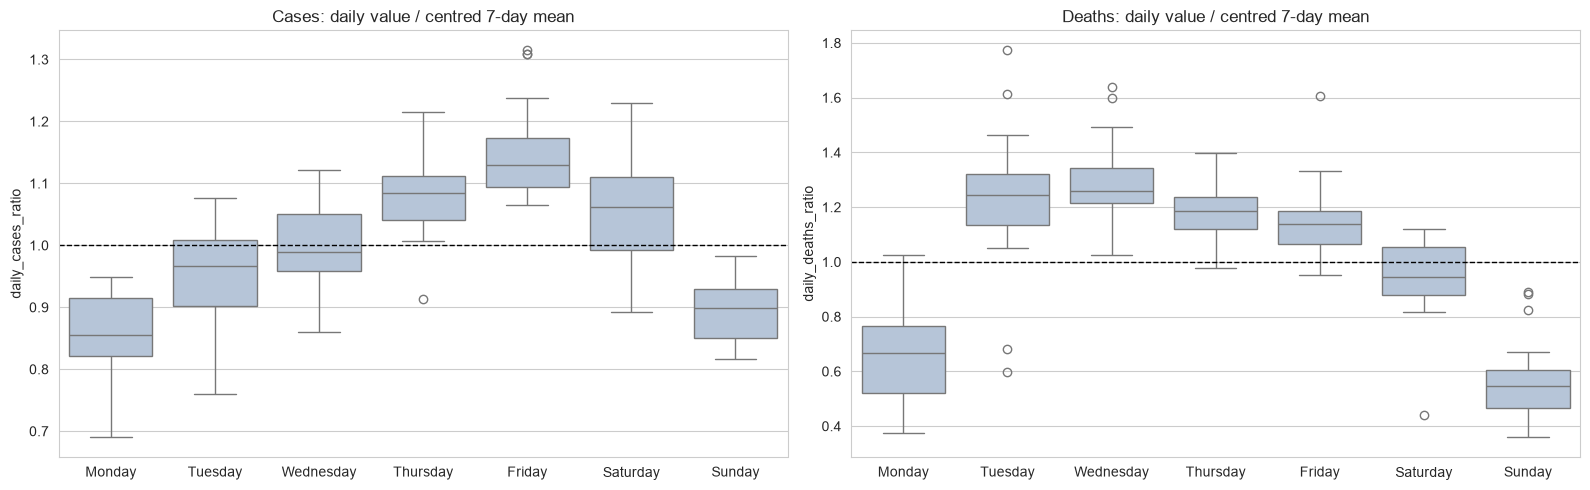

,daily_cases_ratio,daily_deaths_ratio
weekday,,
Monday,0.856,0.666
Tuesday,0.967,1.243
Wednesday,0.990,1.259
Thursday,1.084,1.187
Friday,1.130,1.137
Saturday,1.062,0.947
Sunday,0.898,0.548


In [20]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# each day relative to its centred 7-day mean removes the trend and leaves the weekday shape;
# this ratio describes the data only and is never used as a model input
for col in ["daily_cases", "daily_deaths"]:
    us[col + "_ratio"] = us[col] / us[col].rolling(7, center=True).mean()

# from April the daily counts are in the thousands, so the ratios are not driven by tiny numbers
weekly_eda = us.loc["2020-04-01":].dropna(subset=["daily_cases_ratio", "daily_deaths_ratio"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, title in [(axes[0], "daily_cases_ratio", "Cases"), (axes[1], "daily_deaths_ratio", "Deaths")]:
    sns.boxplot(data=weekly_eda, x="weekday", y=col, order=weekday_order, ax=ax, color="lightsteelblue")
    ax.axhline(1, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{title}: daily value / centred 7-day mean")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

weekly_eda.groupby("weekday")[["daily_cases_ratio", "daily_deaths_ratio"]].median().reindex(weekday_order).round(3)

**Weekly reporting cycle**

To remove the trend, each day was divided by its centred 7-day mean, so a value of 1 means an average day for that week. The ratio only describes the data and is never used as a model input, since a centred mean uses later days.

Observation: the cycle is strong and consistent. For cases, the median Monday ratio is 0.856 and the median Friday ratio 1.130, so a Friday typically reports about 30% more cases than the Monday of the same week. For deaths the swing is much larger: 0.548 on Sundays and 0.666 on Mondays against 1.259 on Wednesdays, more than a twofold difference within a week. The boxes for low and high days hardly overlap.

Interpretation: this is a reporting pattern (fewer reports over weekends and catch-up during the week), not a pattern in infections or deaths themselves. For modelling it means a weekly period of 7 should be built in: a seasonal-naive baseline, seasonal terms in ETS and SARIMA, and weekday features in the regression models. It also suggested a forecast horizon that is a multiple of 7, so every weekday counts equally in the error.

Limitation: the analysis starts in April. Before that, daily counts were small and growing fast, and the ratios would mostly reflect that growth.

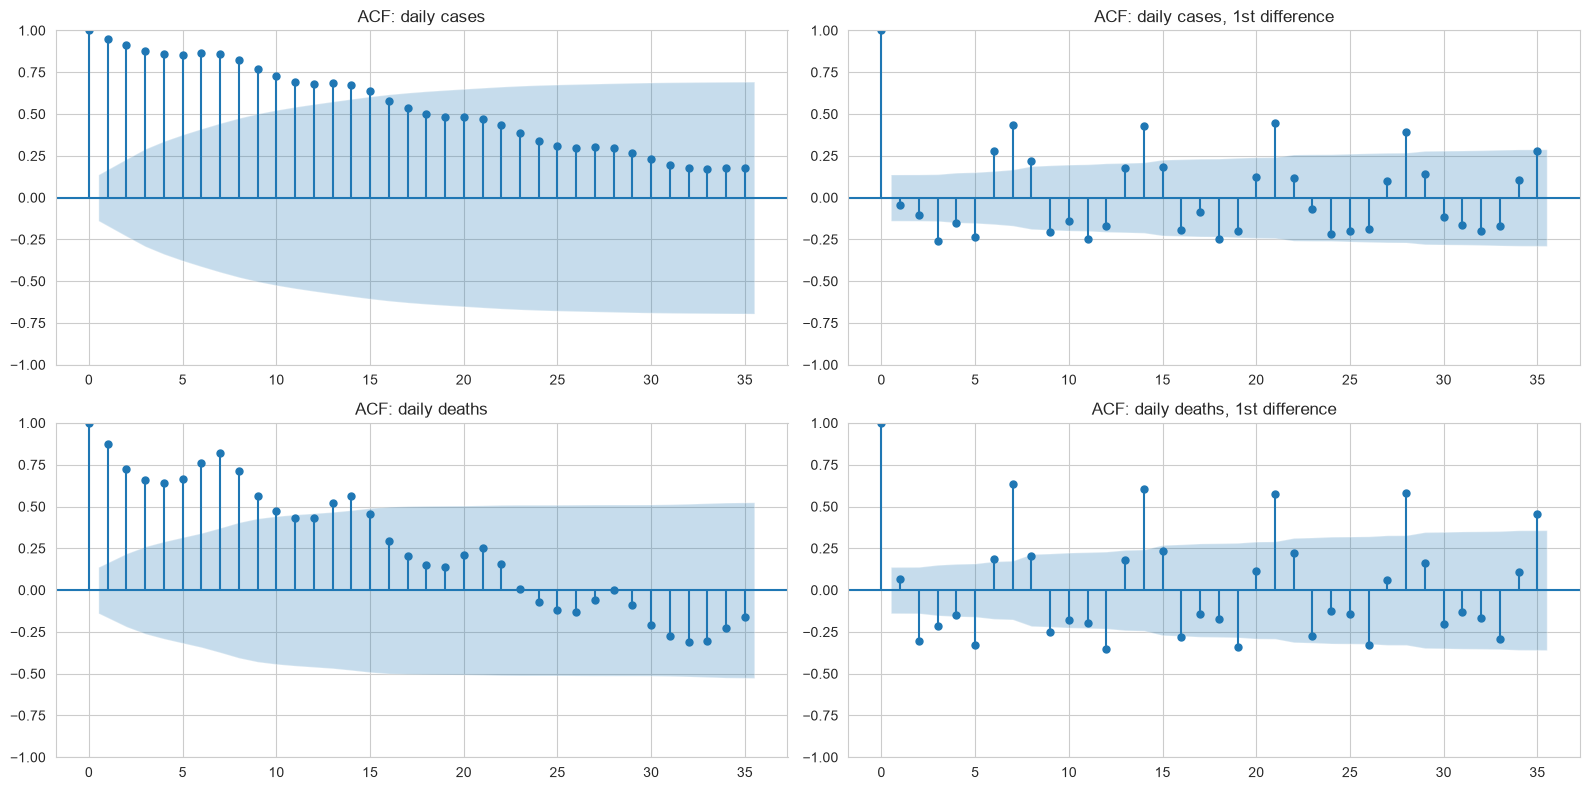

,series,form,adf_stat,p_value
0,daily_cases,level,-2.301,0.1715
1,daily_cases,1st difference,-2.761,0.0641
2,daily_cases,7-day difference,-2.124,0.2349
3,daily_deaths,level,-3.513,0.0076
4,daily_deaths,1st difference,-2.105,0.2426
5,daily_deaths,7-day difference,-2.177,0.2148


In [21]:
active = us.loc[active_start:]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
plot_acf(active["daily_cases"], lags=35, ax=axes[0, 0], title="ACF: daily cases")
plot_acf(active["daily_cases"].diff().dropna(), lags=35, ax=axes[0, 1], title="ACF: daily cases, 1st difference")
plot_acf(active["daily_deaths"], lags=35, ax=axes[1, 0], title="ACF: daily deaths")
plot_acf(active["daily_deaths"].diff().dropna(), lags=35, ax=axes[1, 1], title="ACF: daily deaths, 1st difference")
plt.tight_layout()
plt.show()

adf_rows = []
for col in ["daily_cases", "daily_deaths"]:
    for label, series in [("level", active[col]),
                          ("1st difference", active[col].diff().dropna()),
                          ("7-day difference", active[col].diff(7).dropna())]:
        stat, p_value = adfuller(series, autolag="AIC", result_object=False)[:2]
        adf_rows.append({"series": col, "form": label, "adf_stat": round(stat, 3), "p_value": round(p_value, 4)})
pd.DataFrame(adf_rows)

**Autocorrelation and stationarity**

Observation: in levels, both ACFs decay slowly, which is what a trending series looks like. After first differencing, almost all the remaining structure is at lags 7, 14, 21 and 28 (about 0.4 for cases and 0.6 for deaths). The ADF tests are mixed. For cases, none of the three forms rejects a unit root at the 5% level (p = 0.17 in levels, 0.064 after first differencing, 0.23 after 7-day differencing). For deaths, the level rejects (p = 0.008) but the differenced forms do not (p = 0.24 and 0.21).

Interpretation: the ACF confirms the weekly cycle from a different angle. The ADF results are not consistent enough to choose the amount of differencing. With around 200 observations and several changes of direction, unit-root tests have little power and can be misled by structural breaks, and a "stationary" deaths level is not credible for a series that fell from about 2,200 to about 500 a day and then rose again. So I treated differencing as a modelling choice to compare on validation error (SARIMA with d = 0 and d = 1) instead of deciding it from p-values.

Limitation: the ACF and ADF were computed on the whole active period. That is fine for describing the data, and nothing from this cell is passed into a model.

lag with the highest correlation (days): 1 | r = 0.705


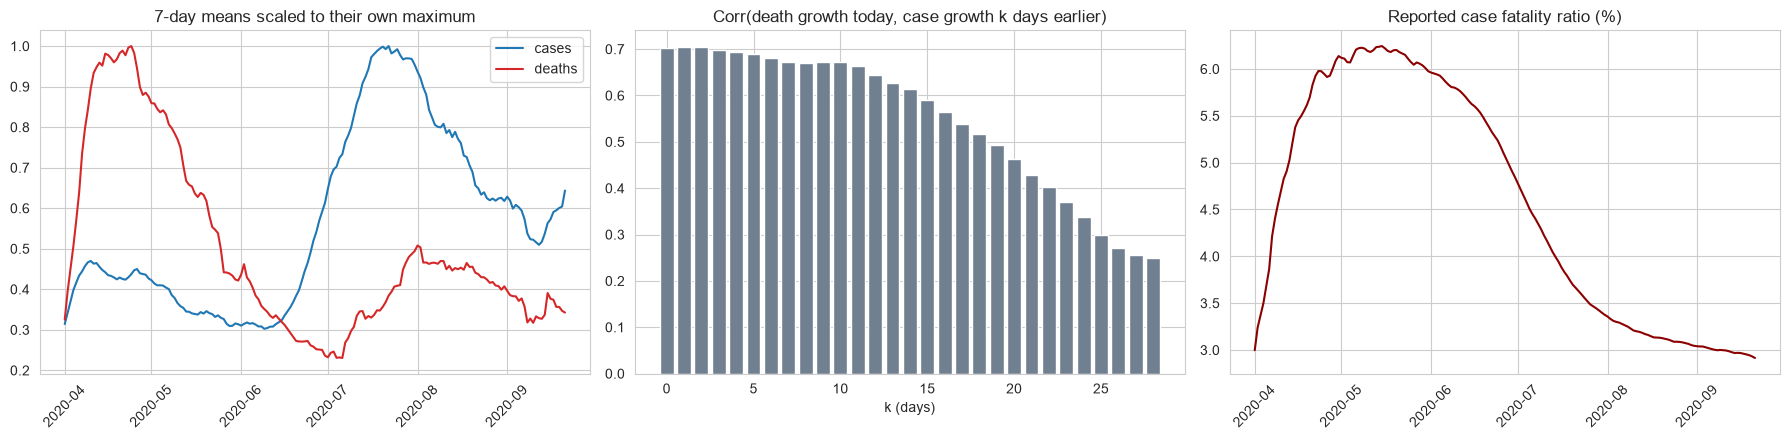

In [22]:
# trailing 7-day means smooth out the weekday cycle; week-over-week log growth removes the shared trend
# so the correlation isn't inflated just because both series rise and fall together
ma7 = us[["daily_cases", "daily_deaths"]].rolling(7).mean()
growth = np.log(ma7.where(ma7 > 0)).diff(7).loc["2020-04-01":]

lags = range(0, 29)
lag_corr = pd.Series([growth["daily_deaths"].corr(growth["daily_cases"].shift(k)) for k in lags], index=lags)
print("lag with the highest correlation (days):", lag_corr.idxmax(), "| r =", round(lag_corr.max(), 3))

reported_cfr = (us["cum_deaths"] / us["cum_cases"]).loc["2020-04-01":] * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(ma7.loc["2020-04-01":, "daily_cases"] / ma7["daily_cases"].max(), label="cases", color="tab:blue")
axes[0].plot(ma7.loc["2020-04-01":, "daily_deaths"] / ma7["daily_deaths"].max(), label="deaths", color="tab:red")
axes[0].set_title("7-day means scaled to their own maximum")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(lag_corr.index, lag_corr.values, color="slategray")
axes[1].set_title("Corr(death growth today, case growth k days earlier)")
axes[1].set_xlabel("k (days)")
axes[2].plot(reported_cfr, color="darkred")
axes[2].set_title("Reported case fatality ratio (%)")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


**How deaths relate to cases**

I compared week-over-week growth in deaths with growth in cases k days earlier. Growth rates were used instead of the raw values so that the correlation isn't inflated just because both series rise and fall over the same months.

Observation: the correlation is highest at a lag of 1 day (r = 0.705), but it is almost the same for lags 0 to about 10 and then fades slowly, with no clear peak. The scaled 7-day means do show the summer death peak arriving after the case peak. The reported case fatality ratio (cumulative deaths divided by cumulative cases) rose to about 6.2% in May and then fell steadily to about 2.9% by mid-September.

Interpretation: this approach did not isolate a lead time. The smoothed growth series change slowly, so neighbouring lags look almost identical. I measured the lag directly from the peak dates instead (next cell). The falling fatality ratio is consistent with more testing finding milder cases, but the data cannot separate that from changes in severity or treatment.

Limitation: the fatality ratio here is a ratio of reported numbers. It is not an infection fatality rate and should not be read as one.

In [23]:
for label, start, end in [("first wave", "2020-03-15", "2020-05-31"), ("second wave", "2020-06-15", "2020-09-21")]:
    window = ma7.loc[start:end]
    case_peak, death_peak = window["daily_cases"].idxmax(), window["daily_deaths"].idxmax()
    print(f"{label}: cases peak {case_peak.date()} | deaths peak {death_peak.date()} | gap {(death_peak - case_peak).days} days")

# a stable deviation-to-level ratio across months points to multiplicative weekly swings
monthly_tables = []
for col in ["daily_cases", "daily_deaths"]:
    abs_dev = (us[col] - us[col].rolling(7, center=True).mean()).abs()
    monthly = pd.DataFrame({"level": us[col], "abs_dev": abs_dev}).loc["2020-04-01":].resample("MS").mean()
    monthly["dev_to_level"] = monthly["abs_dev"] / monthly["level"]
    monthly.columns = pd.MultiIndex.from_product([[col], monthly.columns])
    monthly_tables.append(monthly)
pd.concat(monthly_tables, axis=1).round(3)

first wave: cases peak 2020-04-10 | deaths peak 2020-04-24 | gap 14 days
second wave: cases peak 2020-07-22 | deaths peak 2020-08-01 | gap 10 days


daily_cases                        daily_deaths                      
                 level   abs_dev dev_to_level        level  abs_dev dev_to_level
date                                                                            
2020-04-01   29464.100  2472.419        0.084     2019.433  246.195        0.122
2020-05-01   23434.097  2438.885        0.104     1344.355  306.535        0.228
2020-06-01   27909.667  2445.552        0.088      673.867  161.410        0.240
2020-07-01   62119.129  4799.078        0.077      848.742  226.986        0.267
2020-08-01   47370.323  4710.318        0.099      953.645  293.594        0.308
2020-09-01   39347.476  5048.119        0.128      774.667  280.500        0.362

**Peak timing and the size of weekly swings**

Observation: in the first wave, cases peaked on 10 Apr and deaths on 24 Apr, 14 days later. In the second wave, cases peaked on 22 Jul and deaths on 1 Aug, 10 days later. For cases, the average deviation from the weekly mean stayed between 7.7% and 12.8% of the level while the level itself moved between about 23,000 and 62,000; when the level doubled in July, the absolute deviation also roughly doubled (about 2,400 to 4,800). For deaths, the absolute deviation stayed roughly flat (about 160 to 310) while the level fell from about 2,000 to 775, so the relative weekly swing grew from 12% to 36%.

Interpretation: deaths trail cases by roughly 10 to 14 days, so a rise in cases is an early signal for deaths about two weeks later. For cases, the swings grow with the level, which points to a multiplicative weekly pattern (modelling on a log scale). Deaths fit neither an additive nor a multiplicative pattern: their weekly cycle became relatively stronger over time. Since the evidence doesn't clearly favour one scale, raw and log versions of the models are compared on validation.

Limitation: two waves give only two peak-to-peak lags, so 10 to 14 days is a rough guide rather than a precise estimate.

## 6. Forecasting problem: target, horizon and validation design

**Targets.** Daily new confirmed cases (primary) and daily new deaths (secondary) for the US. Both series are clean and they behave differently enough to be worth forecasting separately. I did not use cumulative totals as targets: a cumulative forecast hides the day-to-day errors that matter for planning, and almost any model looks accurate on a series that only goes up.

**Horizon: 14 days.** This is two full weekly cycles, so every weekday is weighted equally in the error. The series changed direction every six to eight weeks, so a longer horizon would mostly measure luck. Two weeks is also a realistic lead time for staffing and supply decisions.

**Validation design.** Everything is chronological.
- Holdout test: the last 28 days (25 Aug to 21 Sep), kept out of all development decisions. It is evaluated as two 14-day forecasts made on 24 Aug and 7 Sep, each using only data up to that date. This mirrors how the model would be used: re-run every two weeks on the latest data.
- Validation: rolling-origin evaluation with 8 weekly origins from 22 Jun to 10 Aug, each forecasting the next 14 days. Models are refitted at every origin on all data up to it (an expanding window). The window covers the rise, peak and decline of the summer wave, so every model is tested on rising, flat and falling periods before it reaches the holdout.

A random train/test split would put future days into training, so it isn't appropriate here.

,set,origin,train_days,forecast_from,forecast_to
0,validation,2020-06-22,111,2020-06-23,2020-07-06
1,validation,2020-06-29,118,2020-06-30,2020-07-13
2,validation,2020-07-06,125,2020-07-07,2020-07-20
3,validation,2020-07-13,132,2020-07-14,2020-07-27
4,validation,2020-07-20,139,2020-07-21,2020-08-03
5,validation,2020-07-27,146,2020-07-28,2020-08-10
6,validation,2020-08-03,153,2020-08-04,2020-08-17
7,validation,2020-08-10,160,2020-08-11,2020-08-24
8,test,2020-08-24,174,2020-08-25,2020-09-07
9,test,2020-09-07,188,2020-09-08,2020-09-21


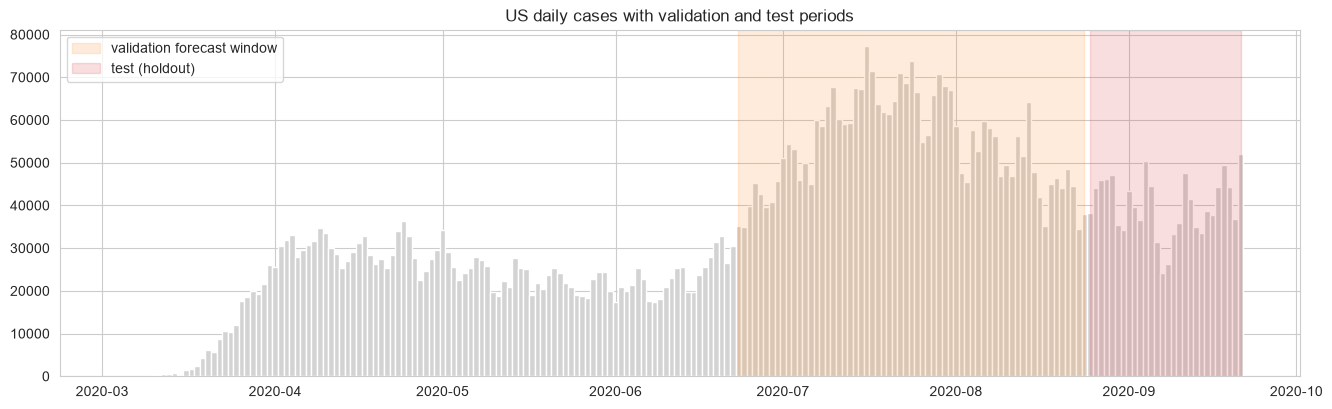

In [24]:
HORIZON = 14
TEST_START = pd.Timestamp("2020-08-25")
one_day = pd.Timedelta(days=1)

# an origin is the last day of data a model sees; it forecasts the following HORIZON days
val_origins = pd.date_range(end=TEST_START - one_day - pd.Timedelta(days=HORIZON), periods=8, freq="7D")
test_origins = pd.DatetimeIndex([TEST_START - one_day, TEST_START - one_day + pd.Timedelta(days=HORIZON)])

folds = pd.DataFrame([
    {"set": set_name, "origin": o.date(), "train_days": len(us.loc[active_start:o]),
     "forecast_from": (o + one_day).date(), "forecast_to": (o + pd.Timedelta(days=HORIZON)).date()}
    for set_name, origins in [("validation", val_origins), ("test", test_origins)]
    for o in origins
])
display(folds)

# the test forecasts end exactly on the last date in the data, and validation never reaches the test period
assert test_origins[-1] + pd.Timedelta(days=HORIZON) == us.index[-1]
assert val_origins[-1] + pd.Timedelta(days=HORIZON) < TEST_START

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.bar(us.loc[active_start:].index, us.loc[active_start:, "daily_cases"], color="lightgray", width=1)
ax.axvspan(val_origins[0] + one_day, TEST_START - one_day, color="tab:orange", alpha=0.15, label="validation forecast window")
ax.axvspan(TEST_START, us.index[-1], color="tab:red", alpha=0.15, label="test (holdout)")
ax.set_title("US daily cases with validation and test periods")
ax.legend(loc="upper left")
plt.show()

The fold table and the assertions confirm the design: the first validation fold trains on 111 days, the last test fold ends exactly on 21 Sep, and no validation forecast reaches the test period. The chart shows where the validation forecast windows and the holdout fall on the series.

## 7. Model development and validation

**Evaluation framework.** The `evaluate` function gives each model only the history up to the origin, so a model can never see the period it is forecasting. Every model, from the baselines to Gradient Boosting, goes through the same function and the same folds.

**Metrics.**
- MAE: the average miss in cases or deaths per day, the easiest number to relate to planning.
- RMSE: penalises large misses more heavily, and large misses are what matter for capacity.
- MAPE: puts cases and deaths on a comparable percentage scale. It is safe here because the US active period has no zero days.

Fitting time is recorded for every model so accuracy can be weighed against cost. Accuracy in the classification sense has no meaning for a continuous forecast, so it is not used.

In [25]:
targets = ["daily_cases", "daily_deaths"]

def metrics(actual, predicted):
    err = actual - predicted
    return {
        "MAE": np.mean(np.abs(err)),
        "RMSE": np.sqrt(np.mean(err ** 2)),
        "MAPE": np.mean(np.abs(err) / actual) * 100,
    }

def evaluate(forecast_fn, target, origins, name):
    # the model only ever receives history up to the origin, so the forecast window stays unseen
    fold_rows, pred_frames = [], []
    start = time.perf_counter()
    for origin in origins:
        history = us.loc[active_start:origin, target].asfreq("D")
        actual = us.loc[origin + one_day: origin + pd.Timedelta(days=HORIZON), target]
        forecast = np.asarray(forecast_fn(history), dtype=float)
        assert len(forecast) == HORIZON
        pred_frames.append(pd.DataFrame({"origin": origin, "actual": actual.values, "forecast": forecast},
                                        index=actual.index))
        fold_rows.append({"origin": origin.date(), **metrics(actual.values, forecast)})
    seconds = time.perf_counter() - start
    fold_scores = pd.DataFrame(fold_rows)
    summary = {"model": name, "target": target,
               **fold_scores[["MAE", "RMSE", "MAPE"]].mean().to_dict(), "seconds": seconds}
    return summary, fold_scores, pd.concat(pred_frames)

val_results, val_fold_scores, val_preds = [], {}, {}

def run_validation(fn, target, name):
    summary, fold_scores, preds = evaluate(fn, target, val_origins, name)
    val_results.append(summary)
    val_fold_scores[(name, target)] = fold_scores
    val_preds[(name, target)] = preds

### 7.1 Baselines
Naive repeats the last observed value for all 14 days. Seasonal naive repeats the last observed week twice, keeping the weekly reporting pattern. Given how strong that pattern is, seasonal naive is the real benchmark.

In [26]:
def naive_forecast(history):
    return np.repeat(history.iloc[-1], HORIZON)

# the day after the origin falls on the same weekday as the first of the last 7 observed days
def seasonal_naive_forecast(history):
    return np.tile(history.iloc[-7:].values, HORIZON // 7)

for target in targets:
    run_validation(naive_forecast, target, "Naive (last value)")
    run_validation(seasonal_naive_forecast, target, "Seasonal naive (last week)")

pd.DataFrame(val_results).round(2)

,model,target,MAE,RMSE,MAPE,seconds
0,Naive (last value),daily_cases,10652.73,11902.49,19.07,0.01
1,Seasonal naive (last week),daily_cases,10687.86,11829.74,20.07,0.01
2,Naive (last value),daily_deaths,413.11,483.11,44.74,0.01
3,Seasonal naive (last week),daily_deaths,169.14,216.16,20.93,0.01


Observation: for cases, both baselines have an MAE of about 10,650 to 10,690 (MAPE about 19 to 20%), and seasonal naive is no better than naive. For deaths, seasonal naive (MAE 169, MAPE 20.9%) is far better than naive (MAE 413, MAPE 44.7%).

Interpretation: the validation window runs through the steep July rise and the August decline. Over two weeks the trend moved the level of cases by more than the weekday cycle does, so repeating last week builds in a level that is already out of date. Deaths are the opposite: get the weekday pattern wrong and the forecast is poor whatever else it does.

### 7.2 Exponential smoothing (Holt-Winters)
ETS with an additive damped trend and a weekly seasonal component. The trend lets it follow rises and falls, and damping stops it from extending the trend at full strength for all 14 days. Two choices were compared on validation:
- raw or log scale: additive seasonality on the log scale is multiplicative on the original scale, so this tests the question raised by the weekly-swing analysis;
- full history or the last 56 days (8 weeks, about one phase of the outbreak): a shorter window might adapt better to the changing weekly pattern in deaths.

In [27]:
def ets_forecast(history, log_scale):
    y = np.log(history) if log_scale else history.astype(float)
    fitted = ExponentialSmoothing(y, trend="add", damped_trend=True, seasonal="add",
                                  seasonal_periods=7, initialization_method="estimated").fit()
    forecast = fitted.forecast(HORIZON)
    return np.exp(forecast) if log_scale else forecast

# 56 days = 8 full weeks, roughly the length of one regime seen in the EDA
for target in targets:
    for log_scale in [False, True]:
        for window in [None, 56]:
            name = (f"ETS damped | {'log' if log_scale else 'raw'} scale | "
                    f"{'full history' if window is None else f'last {window} days'}")
            fn = lambda h, ls=log_scale, w=window: ets_forecast(h if w is None else h.iloc[-w:], ls)
            run_validation(fn, target, name)

pd.DataFrame(val_results).sort_values(["target", "MAE"]).round(2)

,model,target,MAE,RMSE,MAPE,seconds
6,ETS damped | log scale | full history,daily_cases,7101.97,8434.63,12.86,0.76
5,ETS damped | raw scale | last 56 days,daily_cases,7413.30,8522.71,13.51,0.71
7,ETS damped | log scale | last 56 days,daily_cases,7563.81,9096.08,13.65,0.64
4,ETS damped | raw scale | full history,daily_cases,7913.16,9030.62,14.91,0.93
0,Naive (last value),daily_cases,10652.73,11902.49,19.07,0.01
1,Seasonal naive (last week),daily_cases,10687.86,11829.74,20.07,0.01
3,Seasonal naive (last week),daily_deaths,169.14,216.16,20.93,0.01
8,ETS damped | raw scale | full history,daily_deaths,185.60,225.22,24.83,0.69
9,ETS damped | raw scale | last 56 days,daily_deaths,204.20,244.08,29.33,0.91
11,ETS damped | log scale | last 56 days,daily_deaths,215.43,253.56,25.97,0.77


Observation: for cases, all four ETS versions beat both baselines. The best, log scale with full history, has an MAE of 7,102 against 10,688 for seasonal naive (34% lower) and a MAPE of 12.9%. The four versions are within about 10% of each other. For deaths, no ETS version beats seasonal naive; the best is raw scale with full history (MAE 186 against 169). The log scale is clearly worse for deaths (270 against 186 with full history). No ETS fit raised a convergence warning.

Interpretation: for cases, following the trend matters more than reproducing last week, and that is what ETS adds. For deaths, the log-scale result agrees with the weekly-swing analysis: death swings are not proportional to the level, so multiplicative seasonality is the wrong structure. I expected the 56-day window to help deaths cope with the changing weekly pattern, but it did not (204 against 186). A shorter history probably makes the trend and seasonal estimates noisier, and that outweighs the benefit of adapting faster.

In [28]:
compare = {
    "daily_cases": ["Seasonal naive (last week)", "ETS damped | log scale | full history",
                    "ETS damped | raw scale | full history", "ETS damped | raw scale | last 56 days"],
    "daily_deaths": ["Seasonal naive (last week)", "ETS damped | raw scale | full history",
                     "ETS damped | raw scale | last 56 days"],
}
for target, names in compare.items():
    fold_mae = pd.DataFrame({n: val_fold_scores[(n, target)].set_index("origin")["MAE"] for n in names})
    print(target)
    display(fold_mae.round(0))
    beats_baseline = (fold_mae.drop(columns="Seasonal naive (last week)")
                      .lt(fold_mae["Seasonal naive (last week)"], axis=0).sum())
    print("folds (out of 8) beating seasonal naive:")
    print(beats_baseline.to_string(), "\n")

daily_cases


,Seasonal naive (last week),ETS damped | log scale | full history,ETS damped | raw scale | full history,ETS damped | raw scale | last 56 days
origin,,,,
2020-06-22,16230.0,3277.0,6481.0,4762.0
2020-06-29,15483.0,6660.0,5252.0,3062.0
2020-07-06,14842.0,5815.0,12507.0,13689.0
2020-07-13,5982.0,12305.0,8040.0,10553.0
2020-07-20,6145.0,9952.0,6634.0,7503.0
2020-07-27,7852.0,5631.0,4305.0,3640.0
2020-08-03,9283.0,4965.0,6229.0,8419.0
2020-08-10,9687.0,8211.0,13857.0,7679.0


folds (out of 8) beating seasonal naive:
ETS damped | log scale | full history    6
ETS damped | raw scale | full history    5
ETS damped | raw scale | last 56 days    6 

daily_deaths


,Seasonal naive (last week),ETS damped | raw scale | full history,ETS damped | raw scale | last 56 days
origin,,,
2020-06-22,73.0,79.0,135.0
2020-06-29,164.0,188.0,223.0
2020-07-06,271.0,306.0,334.0
2020-07-13,196.0,174.0,206.0
2020-07-20,232.0,145.0,198.0
2020-07-27,221.0,216.0,204.0
2020-08-03,86.0,261.0,183.0
2020-08-10,110.0,117.0,150.0


folds (out of 8) beating seasonal naive:
ETS damped | raw scale | full history    3
ETS damped | raw scale | last 56 days    2 



**Consistency across folds**

Observation: for cases, no ETS version wins every fold and the best version changes from fold to fold. Log scale with full history beats seasonal naive in 6 of 8 folds. Every ETS version loses to seasonal naive in the folds starting 13 Jul and 20 Jul (seasonal naive about 6,000 against 6,634 to 12,305 for ETS). For deaths, ETS raw with full history beats seasonal naive in only 3 of 8 folds, and most of its average gap comes from a single fold (3 Aug: 261 against 86).

Interpretation: the 13 Jul and 20 Jul forecasts were made just before the case peak on 22 Jul. ETS kept extending the July rise past the turning point, while repeating last week happened to be close because the level flattened at the peak. This is the main weakness of trend-following models and it comes up again later. For deaths, seasonal naive's lead is consistent rather than the result of one lucky fold.

### 7.3 SARIMA
SARIMA handles the weekly cycle with seasonal differencing at lag 7, which matches the ACF spikes at 7, 14 and 21. I kept the grid small and chose each order for a reason:
- (0,1,1)(0,1,1,7), the standard "airline" model for trending seasonal series;
- (1,1,1)(0,1,1,7), which adds short-term momentum;
- (1,0,1)(0,1,1,7), with no first difference, to test the option the deaths ADF result hinted at.

Each order was fitted on raw and log scale with the full history (the ETS window test gave no reason to double the grid). Warnings during fitting are counted per model instead of being printed, because a model that often fails to converge is a poor production candidate whatever its score.

In [29]:
sarima_warning_log = {}

def sarima_forecast(history, order, seasonal_order, log_scale, target, name):
    y = np.log(history) if log_scale else history.astype(float)
    # warnings are counted per model instead of printed, since they are evidence about fit stability
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        fitted = SARIMAX(y, order=order, seasonal_order=seasonal_order).fit(disp=False)
    for w in caught:
        key = (target, name, w.category.__name__)
        sarima_warning_log[key] = sarima_warning_log.get(key, 0) + 1
    forecast = fitted.forecast(HORIZON)
    return np.exp(forecast) if log_scale else forecast

# seasonal differencing at lag 7 in every order, matching the ACF spikes at 7, 14, 21;
# d = 0 vs 1 is compared here because the ADF results could not settle it
sarima_orders = [((0, 1, 1), (0, 1, 1, 7)),
                 ((1, 1, 1), (0, 1, 1, 7)),
                 ((1, 0, 1), (0, 1, 1, 7))]

for target in targets:
    for order, seasonal_order in sarima_orders:
        for log_scale in [False, True]:
            name = f"SARIMA {order}{seasonal_order} | {'log' if log_scale else 'raw'} scale"
            fn = (lambda h, o=order, so=seasonal_order, ls=log_scale, t=target, n=name:
                  sarima_forecast(h, o, so, ls, t, n))
            run_validation(fn, target, name)

results_df = pd.DataFrame(val_results)
display(results_df[results_df["model"].str.startswith(("SARIMA", "Seasonal naive"))]
        .sort_values(["target", "MAE"]).round(2))

print("warnings during SARIMA fitting (8 fits per model):")
pd.Series(sarima_warning_log, dtype=int).rename("count")

,model,target,MAE,RMSE,MAPE,seconds
14,"SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale",daily_cases,7747.69,8950.87,14.43,1.89
16,"SARIMA (1, 0, 1)(0, 1, 1, 7) | raw scale",daily_cases,7964.81,9112.85,14.90,1.84
12,"SARIMA (0, 1, 1)(0, 1, 1, 7) | raw scale",daily_cases,8076.21,9264.67,15.02,1.65
17,"SARIMA (1, 0, 1)(0, 1, 1, 7) | log scale",daily_cases,9475.07,10910.17,17.55,2.18
15,"SARIMA (1, 1, 1)(0, 1, 1, 7) | log scale",daily_cases,9532.79,10990.96,17.53,1.83
13,"SARIMA (0, 1, 1)(0, 1, 1, 7) | log scale",daily_cases,9633.39,11092.53,17.75,1.55
1,Seasonal naive (last week),daily_cases,10687.86,11829.74,20.07,0.01
3,Seasonal naive (last week),daily_deaths,169.14,216.16,20.93,0.01
22,"SARIMA (1, 0, 1)(0, 1, 1, 7) | raw scale",daily_deaths,195.63,236.49,24.82,2.35
20,"SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale",daily_deaths,208.83,246.04,27.71,2.66


warnings during SARIMA fitting (8 fits per model):


daily_deaths  SARIMA (0, 1, 1)(0, 1, 1, 7) | log scale  ConvergenceWarning    1
              SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale  EstimationWarning     5
Name: count, dtype: int64

Observation: for cases, the best SARIMA is (1,1,1)(0,1,1,7) on raw scale (MAE 7,748), close to ETS raw (7,913) and behind ETS log (7,102). Here the log scale made every SARIMA version worse (MAE 9,475 or more). For deaths, every SARIMA version loses to seasonal naive; the best, (1,0,1)(0,1,1,7) raw, has an MAE of 196. The (1,1,1)(0,1,1,7) raw deaths model raised an EstimationWarning in 5 of its 8 fits, and the (0,1,1)(0,1,1,7) log deaths model raised one ConvergenceWarning.

Interpretation: the effect of the log scale depends on the model (it helped ETS and hurt SARIMA for cases), so I don't claim the log transform as a general finding for cases. For deaths, no first difference did slightly better than one, in line with the level ADF result, but that matters little when no version beats repeating last week. The (1,1,1) deaths model is unreliable regardless of its score because of the repeated estimation warnings.

### 7.4 Regression models: Ridge and Gradient Boosting

Tree models cannot predict values outside the range they were trained on, and the US level changed a lot, so neither model predicts raw counts. Instead both predict how much each future day will differ from the current weekly level:

target = log(value on day o+h) − log(7-day mean at origin o), for h = 1 to 14

and the forecast is the current level × exp(prediction). This is a direct strategy: one model gives all 14 days at once, so forecast errors are never fed back in as inputs.

Features, all computed from data up to the origin:
- `same_weekday_ratio`: last week's value for the same weekday relative to the current level (the information that makes seasonal naive strong for deaths);
- `growth_1w`, `growth_2w`: change in the weekly level over the last week and the week before;
- `trend_projection` = growth_1w × h / 7: what constant growth would imply at horizon h. Ridge cannot multiply features on its own, so this gives it the trend;
- `h` and weekday dummies;
- deaths only: `case_growth_1w`, `case_growth_2w`. Deaths trail cases by 10 to 14 days, so recent case growth is a legitimate, already known signal for deaths over the next two weeks.

Leakage prevention: training rows are built from the truncated history the evaluator passes in, and a row is kept only if its target day is on or before the fold's origin. Training rows start on 1 Apr, as in the EDA. The Ridge scaler sits inside the pipeline, so it is fitted on training rows only.

Hyperparameters are fixed at standard values (Ridge alpha = 1; Gradient Boosting with 300 trees, learning rate 0.05, depth 3, subsample 0.8). Rows from neighbouring origins overlap heavily, so the effective sample is much smaller than the row count, and tuning on 8 folds would mostly fit noise. I decided to tune only if a model came close to the top.

In [30]:
FEATURE_START = pd.Timestamp("2020-04-01")
week = pd.Timedelta(days=7)

def make_rows(y, origins, case_y=None):
    # every feature for an origin uses values on or before that origin only
    log_level = np.log(y.rolling(7).mean())
    case_log_level = np.log(case_y.rolling(7).mean()) if case_y is not None else None
    rows = []
    for o in origins:
        for h in range(1, HORIZON + 1):
            target_date = o + pd.Timedelta(days=h)
            ref_date = target_date - week * int(np.ceil(h / 7))
            row = {
                "origin": o,
                "target_date": target_date,
                "log_level": log_level.loc[o],
                "weekday": target_date.dayofweek,
                "h": h,
                "growth_1w": log_level.loc[o] - log_level.loc[o - week],
                "growth_2w": log_level.loc[o - week] - log_level.loc[o - 2 * week],
                "same_weekday_ratio": np.log(y.loc[ref_date]) - log_level.loc[o],
            }
            row["trend_projection"] = row["growth_1w"] * h / 7
            if case_y is not None:
                row["case_growth_1w"] = case_log_level.loc[o] - case_log_level.loc[o - week]
                row["case_growth_2w"] = case_log_level.loc[o - week] - case_log_level.loc[o - 2 * week]
            rows.append(row)
    return pd.DataFrame(rows)

def to_matrix(rows):
    X = rows.drop(columns=["origin", "target_date", "log_level", "weekday"]).reset_index(drop=True)
    weekday_dummies = pd.get_dummies(pd.Categorical(rows["weekday"], categories=range(7)),
                                     prefix="dow", dtype=float)
    return pd.concat([X, weekday_dummies], axis=1)

def regression_forecast(history, make_model, target):
    origin = history.index[-1]
    case_y = us.loc[active_start:origin, "daily_cases"] if target == "daily_deaths" else None

    train_rows = make_rows(history, pd.date_range(FEATURE_START, origin - one_day), case_y)
    # a row is usable for training only once its target day has been observed
    train_rows = train_rows[train_rows["target_date"] <= origin]
    y_train = np.log(history.loc[train_rows["target_date"]].values) - train_rows["log_level"].values

    X_train = to_matrix(train_rows)
    assert not X_train.isna().any().any()

    model = make_model()
    model.fit(X_train, y_train)

    future_rows = make_rows(history, [origin], case_y)
    return np.exp(future_rows["log_level"].values + model.predict(to_matrix(future_rows)))

ridge_model = lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0))
gbr_model = lambda: GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3,
                                              subsample=0.8, random_state=42)

In [31]:
for target in targets:
    for name, factory in [("Ridge (direct)", ridge_model), ("Gradient Boosting (direct)", gbr_model)]:
        run_validation(lambda h, f=factory, t=target: regression_forecast(h, f, t), target, name)

results_df = pd.DataFrame(val_results)
results_df["family"] = results_df["model"].str.split(" ").str[0]

# best configuration of each model family, per target
best_per_family = results_df.loc[results_df.groupby(["target", "family"])["MAE"].idxmin()]
display(best_per_family.sort_values(["target", "MAE"]).drop(columns="family").round(2))

for target in targets:
    names = best_per_family[best_per_family["target"] == target].sort_values("MAE")["model"].tolist()
    fold_mae = pd.DataFrame({n: val_fold_scores[(n, target)].set_index("origin")["MAE"] for n in names})
    print(target)
    display(fold_mae.round(0))

,model,target,MAE,RMSE,MAPE,seconds
6,ETS damped | log scale | full history,daily_cases,7101.97,8434.63,12.86,0.76
14,"SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale",daily_cases,7747.69,8950.87,14.43,1.89
24,Ridge (direct),daily_cases,8546.79,9831.33,16.14,2.25
0,Naive (last value),daily_cases,10652.73,11902.49,19.07,0.01
1,Seasonal naive (last week),daily_cases,10687.86,11829.74,20.07,0.01
25,Gradient Boosting (direct),daily_cases,12365.00,13720.12,22.41,7.27
3,Seasonal naive (last week),daily_deaths,169.14,216.16,20.93,0.01
8,ETS damped | raw scale | full history,daily_deaths,185.60,225.22,24.83,0.69
22,"SARIMA (1, 0, 1)(0, 1, 1, 7) | raw scale",daily_deaths,195.63,236.49,24.82,2.35
27,Gradient Boosting (direct),daily_deaths,205.86,247.78,23.79,8.10


daily_cases


,ETS damped | log scale | full history,"SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale",Ridge (direct),Naive (last value),Seasonal naive (last week),Gradient Boosting (direct)
origin,,,,,,
2020-06-22,3277.0,6947.0,13801.0,14019.0,16230.0,15043.0
2020-06-29,6660.0,4659.0,6617.0,14445.0,15483.0,8091.0
2020-07-06,5815.0,6922.0,7141.0,19233.0,14842.0,11711.0
2020-07-13,12305.0,10277.0,9236.0,7950.0,5982.0,21774.0
2020-07-20,9952.0,11694.0,9624.0,7685.0,6145.0,17805.0
2020-07-27,5631.0,7652.0,8167.0,6745.0,7852.0,9314.0
2020-08-03,4965.0,4093.0,6863.0,8342.0,9283.0,8161.0
2020-08-10,8211.0,9738.0,6924.0,6803.0,9687.0,7020.0


daily_deaths


,Seasonal naive (last week),ETS damped | raw scale | full history,"SARIMA (1, 0, 1)(0, 1, 1, 7) | raw scale",Gradient Boosting (direct),Ridge (direct),Naive (last value)
origin,,,,,,
2020-06-22,73.0,79.0,80.0,87.0,70.0,205.0
2020-06-29,164.0,188.0,157.0,209.0,176.0,302.0
2020-07-06,271.0,306.0,269.0,339.0,287.0,432.0
2020-07-13,196.0,174.0,212.0,164.0,240.0,536.0
2020-07-20,232.0,145.0,197.0,231.0,268.0,533.0
2020-07-27,221.0,216.0,309.0,267.0,235.0,293.0
2020-08-03,86.0,261.0,236.0,194.0,216.0,513.0
2020-08-10,110.0,117.0,104.0,156.0,171.0,491.0


Observation: for cases, the ranking is ETS log (7,102), SARIMA (7,748), Ridge (8,547), the two baselines (about 10,700) and Gradient Boosting last (12,365), worse than both baselines. Gradient Boosting's failures are concentrated in the folds before the peak: 21,774 on 13 Jul and 17,805 on 20 Jul. Ridge, third on average, is the best trend model in those two folds (9,236 and 9,624, against 9,952 to 12,305 for ETS and SARIMA). For deaths, seasonal naive stays on top (169), followed by ETS (186), SARIMA (196), Gradient Boosting (206) and Ridge (208).

Interpretation: with only about 80 to 130 training origins per fold, and the strongly rising examples coming mostly from the late-June surge, the trees learned "high growth leads to more growth" from very few cases and pushed it too far. Ridge is shrunk towards the current level and last week's weekday shape, so it overreacts less at turning points. For deaths, even with last week's same-weekday value and case growth as features, the regression models did not beat simply repeating last week. Over this window deaths mostly kept last week's shape at about last week's level, and every model that adds a trend lost a little by doing so.

Gradient Boosting did not come close to the top for either target, so I did not tune it. Searching its hyperparameters on these 8 overlapping folds until it looked competitive would be fitting the validation set.

### 7.5 Forecast combination and model selection

The fold tables show that the top models fail in different folds: Ridge held up at the peak while ETS did not, and for deaths ETS did better than seasonal naive in some of seasonal naive's weaker folds. In that situation an average of forecasts usually helps, because the errors partly cancel. To stop this from becoming another source of tuning:
- the rule was fixed in advance and is the same for both targets: an equal-weight average of the top 3 model families by validation MAE, with no fitted weights;
- it is computed from the stored validation forecasts, so nothing is refitted.

Because the members were chosen using validation results, the combination's validation score is slightly optimistic. The holdout is the fair check.

The production model is selected in this cell, in code, from validation results only: the lowest mean validation MAE per target, with the combination included. This happens before any holdout forecast exists, so the holdout cannot influence the choice.

In [32]:
def summarise_preds(preds, name, target, seconds=np.nan):
    fold_scores = pd.DataFrame([{"origin": o.date(), **metrics(g["actual"].values, g["forecast"].values)}
                                for o, g in preds.groupby("origin")])
    summary = {"model": name, "target": target,
               **fold_scores[["MAE", "RMSE", "MAPE"]].mean().to_dict(), "seconds": seconds}
    return summary, fold_scores

def combine_preds(pred_store, members, target):
    frames = [pred_store[(m, target)] for m in members]
    combo = frames[0][["origin", "actual"]].copy()
    combo["forecast"] = np.mean([f["forecast"].values for f in frames], axis=0)
    return combo

COMBO_NAME = "Average of top 3"
combo_members = {}
for target in targets:
    ranked = best_per_family[best_per_family["target"] == target].sort_values("MAE")
    combo_members[target] = ranked["model"].head(3).tolist()
    combo = combine_preds(val_preds, combo_members[target], target)
    summary, fold_scores = summarise_preds(combo, COMBO_NAME, target, ranked["seconds"].head(3).sum())
    val_results.append(summary)
    val_fold_scores[(COMBO_NAME, target)] = fold_scores
    val_preds[(COMBO_NAME, target)] = combo
    print(target, "->", combo_members[target])

results_df = pd.DataFrame(val_results)
candidates = pd.concat([best_per_family.drop(columns="family"), results_df[results_df["model"] == COMBO_NAME]])
display(candidates.sort_values(["target", "MAE"]).round(2))

# the production choice is fixed here from validation alone, before the holdout is used
chosen_model = candidates.loc[candidates.groupby("target")["MAE"].idxmin()].set_index("target")["model"].to_dict()
print("selected on validation:", chosen_model)

for target in targets:
    fold_mae = pd.DataFrame({n: val_fold_scores[(n, target)].set_index("origin")["MAE"]
                             for n in [COMBO_NAME] + combo_members[target]})
    print(target)
    display(fold_mae.round(0))

daily_cases -> ['ETS damped | log scale | full history', 'SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale', 'Ridge (direct)']
daily_deaths -> ['Seasonal naive (last week)', 'ETS damped | raw scale | full history', 'SARIMA (1, 0, 1)(0, 1, 1, 7) | raw scale']


,model,target,MAE,RMSE,MAPE,seconds
28,Average of top 3,daily_cases,7070.21,8136.15,13.14,4.89
6,ETS damped | log scale | full history,daily_cases,7101.97,8434.63,12.86,0.76
14,"SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale",daily_cases,7747.69,8950.87,14.43,1.89
24,Ridge (direct),daily_cases,8546.79,9831.33,16.14,2.25
0,Naive (last value),daily_cases,10652.73,11902.49,19.07,0.01
1,Seasonal naive (last week),daily_cases,10687.86,11829.74,20.07,0.01
25,Gradient Boosting (direct),daily_cases,12365.00,13720.12,22.41,7.27
29,Average of top 3,daily_deaths,167.94,212.59,21.93,3.05
3,Seasonal naive (last week),daily_deaths,169.14,216.16,20.93,0.01
8,ETS damped | raw scale | full history,daily_deaths,185.60,225.22,24.83,0.69


selected on validation: {'daily_cases': 'Average of top 3', 'daily_deaths': 'Average of top 3'}
daily_cases


,Average of top 3,ETS damped | log scale | full history,"SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale",Ridge (direct)
origin,,,,
2020-06-22,7186.0,3277.0,6947.0,13801.0
2020-06-29,3550.0,6660.0,4659.0,6617.0
2020-07-06,6358.0,5815.0,6922.0,7141.0
2020-07-13,10352.0,12305.0,10277.0,9236.0
2020-07-20,10424.0,9952.0,11694.0,9624.0
2020-07-27,7085.0,5631.0,7652.0,8167.0
2020-08-03,3424.0,4965.0,4093.0,6863.0
2020-08-10,8183.0,8211.0,9738.0,6924.0


daily_deaths


,Average of top 3,Seasonal naive (last week),ETS damped | raw scale | full history,"SARIMA (1, 0, 1)(0, 1, 1, 7) | raw scale"
origin,,,,
2020-06-22,73.0,73.0,79.0,80.0
2020-06-29,167.0,164.0,188.0,157.0
2020-07-06,282.0,271.0,306.0,269.0
2020-07-13,183.0,196.0,174.0,212.0
2020-07-20,188.0,232.0,145.0,197.0
2020-07-27,176.0,221.0,216.0,309.0
2020-08-03,177.0,86.0,261.0,236.0
2020-08-10,98.0,110.0,117.0,104.0


Observation: the combination has the lowest validation MAE for both targets, but only just: 7,070 against 7,102 for ETS on cases (0.4% lower) and 167.9 against 169.1 for seasonal naive on deaths (0.7% lower). Its real advantage is consistency. For cases its worst fold is 10,424, against 12,305 for ETS and 13,801 for Ridge, and it has the lowest RMSE for both targets (8,136 for cases and 212.6 for deaths). It never has the best fold, but it never has a very bad one either.

Selected on validation: the average of the top 3 for both targets.
- Cases: ETS damped (log scale, full history), SARIMA (1,1,1)(0,1,1,7) raw and Ridge (direct).
- Deaths: seasonal naive, ETS damped (raw scale, full history) and SARIMA (1,0,1)(0,1,1,7) raw.

## 8. Holdout test (25 Aug to 21 Sep 2020)
All finalists (the best version of each family plus the combination) were run from the two test origins, 24 Aug and 7 Sep, each refitted on all data up to its origin. With only two origins the holdout ranking is much noisier than the validation ranking over eight, so I read it as a check on the selected model rather than a new competition.

In [33]:
test_finalists = {
    "daily_cases": {
        "Naive (last value)": naive_forecast,
        "Seasonal naive (last week)": seasonal_naive_forecast,
        "ETS damped | log scale | full history": lambda h: ets_forecast(h, True),
        "SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale":
            lambda h: sarima_forecast(h, (1, 1, 1), (0, 1, 1, 7), False, "daily_cases", "SARIMA test"),
        "Ridge (direct)": lambda h: regression_forecast(h, ridge_model, "daily_cases"),
        "Gradient Boosting (direct)": lambda h: regression_forecast(h, gbr_model, "daily_cases"),
    },
    "daily_deaths": {
        "Naive (last value)": naive_forecast,
        "Seasonal naive (last week)": seasonal_naive_forecast,
        "ETS damped | raw scale | full history": lambda h: ets_forecast(h, False),
        "SARIMA (1, 0, 1)(0, 1, 1, 7) | raw scale":
            lambda h: sarima_forecast(h, (1, 0, 1), (0, 1, 1, 7), False, "daily_deaths", "SARIMA test"),
        "Ridge (direct)": lambda h: regression_forecast(h, ridge_model, "daily_deaths"),
        "Gradient Boosting (direct)": lambda h: regression_forecast(h, gbr_model, "daily_deaths"),
    },
}

test_results, test_fold_scores, test_preds = [], {}, {}
for target, models in test_finalists.items():
    for name, fn in models.items():
        summary, fold_scores, preds = evaluate(fn, target, test_origins, name)
        test_results.append(summary)
        test_fold_scores[(name, target)] = fold_scores
        test_preds[(name, target)] = preds
    combo = combine_preds(test_preds, combo_members[target], target)
    combo_seconds = sum(r["seconds"] for r in test_results
                        if r["target"] == target and r["model"] in combo_members[target])
    summary, fold_scores = summarise_preds(combo, COMBO_NAME, target, combo_seconds)
    test_results.append(summary)
    test_fold_scores[(COMBO_NAME, target)] = fold_scores
    test_preds[(COMBO_NAME, target)] = combo

test_df = pd.DataFrame(test_results)
test_df["selected_on_validation"] = [m == chosen_model[t] for m, t in zip(test_df["model"], test_df["target"])]
display(test_df.sort_values(["target", "MAE"]).round(2))

for target in targets:
    fold_mae = pd.DataFrame({n: test_fold_scores[(n, target)].set_index("origin")["MAE"]
                             for n in test_df[test_df["target"] == target]["model"]})
    print(target)
    display(fold_mae.round(0))

print("SARIMA warnings on the test fits:",
      {k: v for k, v in sarima_warning_log.items() if k[1] == "SARIMA test"})

,model,target,MAE,RMSE,MAPE,seconds,selected_on_validation
4,Ridge (direct),daily_cases,4764.20,6190.80,12.13,0.74,False
5,Gradient Boosting (direct),daily_cases,5160.73,6846.16,12.88,2.31,False
1,Seasonal naive (last week),daily_cases,5253.79,7512.80,14.47,0.00,False
6,Average of top 3,daily_cases,6422.13,7909.08,15.89,1.83,True
3,"SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale",daily_cases,7605.76,9130.66,18.75,0.83,False
2,ETS damped | log scale | full history,daily_cases,7613.86,9148.85,18.53,0.25,False
0,Naive (last value),daily_cases,10817.29,12111.19,26.55,0.00,False
9,ETS damped | raw scale | full history,daily_deaths,118.89,162.58,17.73,0.22,False
13,Average of top 3,daily_deaths,124.64,166.58,19.83,1.15,True
10,"SARIMA (1, 0, 1)(0, 1, 1, 7) | raw scale",daily_deaths,124.67,166.99,19.53,0.93,False


daily_cases


,Naive (last value),Seasonal naive (last week),ETS damped | log scale | full history,"SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale",Ridge (direct),Gradient Boosting (direct),Average of top 3
origin,,,,,,,
2020-08-24,6159.0,3972.0,3571.0,3335.0,3688.0,3744.0,3172.0
2020-09-07,15476.0,6535.0,11656.0,11876.0,5841.0,6578.0,9672.0


daily_deaths


,Naive (last value),Seasonal naive (last week),ETS damped | raw scale | full history,"SARIMA (1, 0, 1)(0, 1, 1, 7) | raw scale",Ridge (direct),Gradient Boosting (direct),Average of top 3
origin,,,,,,,
2020-08-24,464.0,129.0,102.0,105.0,114.0,94.0,106.0
2020-09-07,500.0,164.0,136.0,144.0,156.0,160.0,144.0


SARIMA warnings on the test fits: {}


Observation (deaths): the combination came second (MAE 124.6), just behind ETS raw (118.9) and close to SARIMA (124.7) and Gradient Boosting (127.0). Seasonal naive, the best single model in validation, dropped to sixth (146.1).

Observation (cases): the combination came fourth (MAE 6,422). Ridge was best (4,764), then Gradient Boosting (5,161) and seasonal naive (5,254), with SARIMA (7,606) and ETS (7,614) behind. The split by origin explains it. From 24 Aug the combination had the lowest error of all models (3,172) and the individual trend models were between 3,335 and 3,744. From 7 Sep, ETS (11,656) and SARIMA (11,876) missed badly while Ridge (5,841) and seasonal naive (6,535) held up. No SARIMA warnings were raised on the test fits.

Interpretation: for deaths, the holdout supports averaging. There was no way to know in advance which single model would hold up (the validation winner dropped to sixth), and the combination stayed near the top in both periods. For cases, two of the three members (ETS and SARIMA) are trend-following state-space models with the same weakness, so averaging them adds little diversity, and Ridge, the member that behaves differently, has only a third of the weight. Gradient Boosting's second place on cases does not change my view of it: it was the worst model in validation with two severe failures, and a good result on two origins after that is more likely luck than reliability.

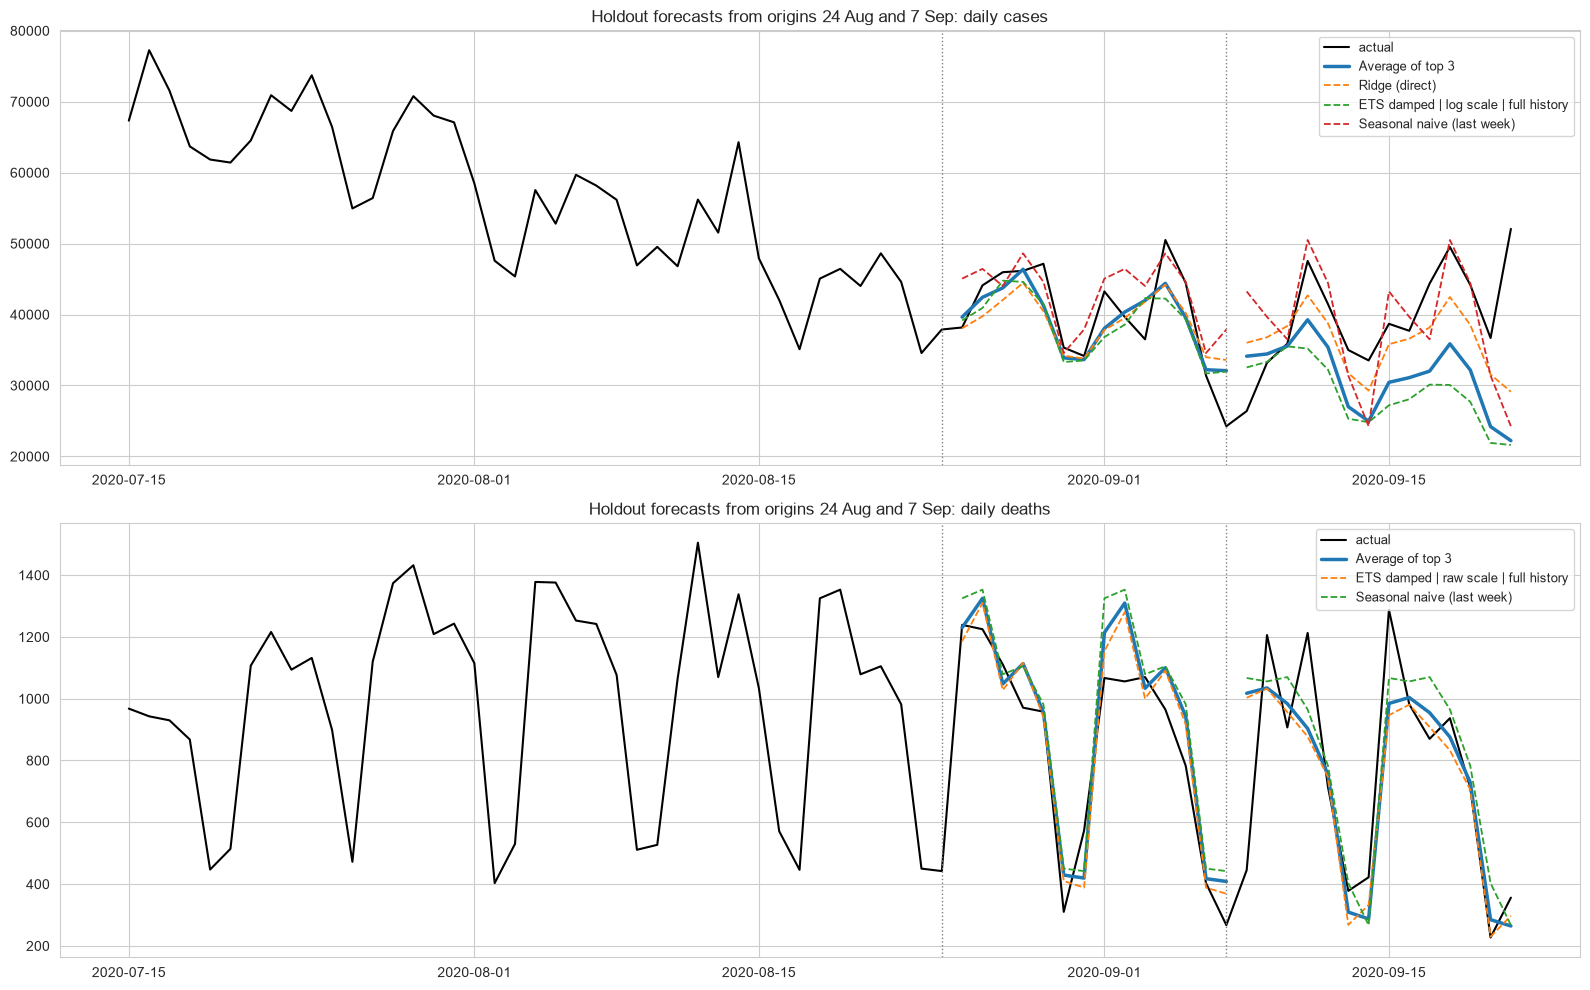

In [39]:
plot_models = {
    "daily_cases": [COMBO_NAME, "Ridge (direct)", "ETS damped | log scale | full history",
                    "Seasonal naive (last week)"],
    "daily_deaths": [COMBO_NAME, "ETS damped | raw scale | full history", "Seasonal naive (last week)"],
}
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for ax, (target, names) in zip(axes, plot_models.items()):
    ax.plot(us.loc["2020-07-15":, target], color="black", linewidth=1.5, label="actual")
    for k, name in enumerate(names):
        for i, (origin, g) in enumerate(test_preds[(name, target)].groupby("origin")):
            ax.plot(g.index, g["forecast"], color=palette[k],
                    linewidth=2.5 if name == COMBO_NAME else 1.3,
                    linestyle="-" if name == COMBO_NAME else "--",
                    label=name if i == 0 else None)
    for origin in test_origins:
        ax.axvline(origin, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"Holdout forecasts from origins 24 Aug and 7 Sep: {target.replace('_', ' ')}")
    ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

**What went wrong from the 7 Sep origin**

Observation: the cases series drops sharply around the 7 Sep origin, which was Labor Day. From that origin ETS (green) stayed well below the actual values for most of the two weeks, while actual cases rose into the 40,000s and reached 52,070 on 21 Sep. Ridge and seasonal naive stayed much closer. Deaths show the same holiday effect: on 8 Sep, the Tuesday after Labor Day, 445 deaths were reported when the models expected about 1,000, followed by higher values later that week (1,206 on 9 Sep and 1,213 on 11 Sep).

Interpretation: ETS and SARIMA react strongly to the latest observations, so holiday-depressed values at the forecast origin pulled their whole two-week path down, and then cases turned upward. Ridge and seasonal naive work from the 7-day level and last week's shape, so a few low days moved them much less. This is the same turning-point weakness seen before the July peak, now in the other direction and made worse by a holiday.

Limitation: no model in this project knows about public holidays, so holiday effects inside a forecast window show up as errors.

## 9. Model comparison report and production model
The table brings together validation (8 origins) and holdout (2 origins) for every finalist, with the number of folds in which each model beat seasonal naive and its fitting time. It is built from the stored results, so every value comes from the runs above. Fitting times are in seconds for all folds together and change slightly from run to run.

In [43]:
def folds_beating_baseline(store, name, target):
    baseline = store[("Seasonal naive (last week)", target)]["MAE"].values
    return int((store[(name, target)]["MAE"].values < baseline).sum())

val_df = pd.DataFrame(val_results)
report = val_df.merge(test_df.drop(columns="selected_on_validation"),
                      on=["model", "target"], suffixes=("_val", "_test"))
report["val_folds_beating_snaive"] = [folds_beating_baseline(val_fold_scores, m, t)
                                      for m, t in zip(report["model"], report["target"])]
report["test_folds_beating_snaive"] = [folds_beating_baseline(test_fold_scores, m, t)
                                       for m, t in zip(report["model"], report["target"])]
report["production"] = [m == chosen_model[t] for m, t in zip(report["model"], report["target"])]

report = report[["target", "model", "MAE_val", "RMSE_val", "MAPE_val", "val_folds_beating_snaive",
                 "MAE_test", "RMSE_test", "MAPE_test", "test_folds_beating_snaive",
                 "seconds_val", "seconds_test", "production"]]
report.sort_values(["target", "MAE_val"]).round(2).reset_index(drop=True)

,target,model,MAE_val,RMSE_val,MAPE_val,val_folds_beating_snaive,MAE_test,RMSE_test,MAPE_test,test_folds_beating_snaive,seconds_val,seconds_test,production
0,daily_cases,Average of top 3,7070.21,8136.15,13.14,6,6422.13,7909.08,15.89,1,5.28,1.86,True
1,daily_cases,ETS damped | log scale | full history,7101.97,8434.63,12.86,6,7613.86,9148.85,18.53,1,0.84,0.27,False
2,daily_cases,"SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale",7747.69,8950.87,14.43,5,7605.76,9130.66,18.75,1,2.07,0.86,False
3,daily_cases,Ridge (direct),8546.79,9831.33,16.14,5,4764.20,6190.80,12.13,2,2.37,0.74,False
4,daily_cases,Naive (last value),10652.73,11902.49,19.07,5,10817.29,12111.19,26.55,0,0.02,0.00,False
5,daily_cases,Seasonal naive (last week),10687.86,11829.74,20.07,0,5253.79,7512.80,14.47,0,0.02,0.00,False
6,daily_cases,Gradient Boosting (direct),12365.00,13720.12,22.41,5,5160.73,6846.16,12.88,1,6.79,2.76,False
7,daily_deaths,Average of top 3,167.94,212.59,21.93,5,124.64,166.58,19.83,2,3.05,1.11,True
8,daily_deaths,Seasonal naive (last week),169.14,216.16,20.93,0,146.11,185.46,24.35,0,0.01,0.00,False
9,daily_deaths,ETS damped | raw scale | full history,185.60,225.22,24.83,3,118.89,162.58,17.73,2,0.74,0.20,False


### Comparison

Daily cases:
- ETS, SARIMA, Ridge and the combination beat both baselines clearly in validation (MAE 7,070 to 8,547 against about 10,700).
- The combination had the lowest validation MAE and RMSE and beat seasonal naive in 6 of 8 folds. On the holdout it lost to seasonal naive (6,422 against 5,254) and beat it in only 1 of the 2 folds.
- Ridge was third in validation but best on the holdout (4,764), and it was the steadiest trend model at both turning points (before the July peak and after Labor Day).
- Gradient Boosting was the worst model in validation (12,365) and is not reliable on this data.
- Plain naive beat seasonal naive in 5 of 8 validation folds for cases: during strong trends the latest level matters more than last week's shape.

Daily deaths:
- Seasonal naive was the best single model in validation (169) but sixth on the holdout (146).
- The combination was first in validation (167.9) and second on the holdout (124.6, just behind ETS at 118.9).
- Plain naive was by far the worst in both periods (413 and 482), confirming that the weekly cycle has to be modelled.

Cost: all of these models are cheap. The baselines are instant, ETS needs well under a second for all 8 folds, SARIMA and Ridge a couple of seconds, and Gradient Boosting several seconds. The combination costs the sum of its members, a few seconds per forecast round, which is negligible for a forecast produced once or twice a week. Gradient Boosting's extra cost bought no accuracy here.

### Production model recommendation

For both targets I recommend the **equal-weight average of the top 3 models** selected on validation:
- cases: ETS damped (log scale) + SARIMA (1,1,1)(0,1,1,7) + Ridge (direct);
- deaths: seasonal naive + ETS damped (raw scale) + SARIMA (1,0,1)(0,1,1,7).

Reasons:
1. It had the lowest validation error for both targets and, more importantly, the most consistent errors, with no fold among the worst.
2. For deaths it held up on the holdout while the best single validation model did not.
3. Each member is a standard method that can be explained, and the average is transparent. When the members disagree, that disagreement is visible and is useful information in itself.
4. It is cheap to refit at every forecast round.

Why I did not switch to Ridge for cases after the holdout: the production choice was fixed before the holdout, and choosing Ridge now would mean selecting on two test origins against eight validation origins where Ridge was about 20% behind. Its holdout score would then no longer be an honest estimate. The holdout result is still important evidence, and it shapes how the model should be run.

How the model would be used in practice:
- Each week (or every two weeks), refit all members on the full history up to the latest complete day and publish a 14-day forecast with the 80% band and each member's forecast.
- Before refitting, check the last few days for incomplete reporting (like India's zero on 21 Sep) and for unusual values at the forecast origin (like the US value on 21 Sep, below), and run a sensitivity check when one is found.
- Track the rolling MAE of the combination, each member and seasonal naive on new data. If Ridge keeps doing better at turning points, increase its weight, but decide that on new forecast rounds, not on this holdout.
- Treat a holiday at or just before the origin as a warning that the ETS and SARIMA forecasts may be pulled down.

This recommendation is specific to US national data from March to September 2020, a 14-day horizon and these evaluation periods. It is not a claim about the best COVID-19 forecasting model in general.

## 10. Production forecast: 22 Sep to 5 Oct 2020
The members of each combination were refitted on all data up to 21 Sep, the last date in the data, exactly as in every evaluation fold, and their forecasts averaged.

The 80% band is empirical. It comes from the combination's own out-of-sample errors on all 10 origins (8 validation and 2 test), as the 10th and 90th percentiles of log(actual / forecast), separately for days 1 to 7 and days 8 to 14. It shows how far off the model was during summer 2020, not a formal probability guarantee. Using the test errors here is fine because the model had already been chosen; they are only used to size the band.

The first line checks how the last observed day compares with its own week, because that day sits at the forecast origin.

In [40]:
FINAL_ORIGIN = us.index[-1]
last_week = us.loc[FINAL_ORIGIN - pd.Timedelta(days=6):FINAL_ORIGIN]
print("21 Sep relative to its week's mean:",
      {t: round(last_week[t].iloc[-1] / last_week[t].mean(), 3) for t in targets})

final_forecasts, interval_tables = {}, {}
for target in targets:
    # empirical 80% band from every out-of-sample combination error: 8 validation + 2 test origins
    errors = pd.concat([val_preds[(COMBO_NAME, target)], test_preds[(COMBO_NAME, target)]])
    errors["h"] = (errors.index.to_numpy() - errors["origin"].to_numpy()) // np.timedelta64(1, "D")
    errors["week_ahead"] = np.where(errors["h"] <= 7, "days 1-7", "days 8-14")
    errors["log_ratio"] = np.log(errors["actual"] / errors["forecast"])
    errors["abs_pct_error"] = (errors["actual"] - errors["forecast"]).abs() / errors["actual"] * 100
    band = errors.groupby("week_ahead")["log_ratio"].quantile([0.1, 0.9]).unstack()
    interval_tables[target] = (errors.groupby("week_ahead")
                               .agg(n=("log_ratio", "size"), MAPE=("abs_pct_error", "mean"))
                               .join(band))

    # members are refitted on all data up to 21 Sep, exactly as in each evaluation fold
    history = us.loc[active_start:FINAL_ORIGIN, target].asfreq("D")
    future_dates = pd.date_range(FINAL_ORIGIN + one_day, periods=HORIZON, freq="D")
    fc = pd.DataFrame({name: np.asarray(test_finalists[target][name](history), dtype=float)
                       for name in combo_members[target]}, index=future_dates)
    fc["forecast"] = fc[combo_members[target]].mean(axis=1)
    week_ahead = np.where(np.arange(1, HORIZON + 1) <= 7, "days 1-7", "days 8-14")
    fc["lower_80"] = fc["forecast"] * np.exp(band.loc[week_ahead, 0.1].to_numpy())
    fc["upper_80"] = fc["forecast"] * np.exp(band.loc[week_ahead, 0.9].to_numpy())
    fc.insert(0, "weekday", fc.index.day_name())
    final_forecasts[target] = fc

for target in targets:
    fc = final_forecasts[target]
    print(f"\n{target} | last observed week: {int(last_week[target].sum()):,}"
          f" | forecast week 1: {int(fc['forecast'].iloc[:7].sum()):,}"
          f" | forecast week 2: {int(fc['forecast'].iloc[7:].sum()):,}")
    display(interval_tables[target].round(3))
    display(fc.round(0))

21 Sep relative to its week's mean: {'daily_cases': np.float64(1.202), 'daily_deaths': np.float64(0.464)}

daily_cases | last observed week: 303,232 | forecast week 1: 383,044 | forecast week 2: 423,993


,n,MAPE,0.1,0.9
week_ahead,,,,
days 1-7,70,9.654,-0.140,0.150
days 8-14,70,17.726,-0.277,0.259


,weekday,ETS damped | log scale | full history,"SARIMA (1, 1, 1)(0, 1, 1, 7) | raw scale",Ridge (direct),forecast,lower_80,upper_80
2020-09-22,Tuesday,48222.0,50263.0,49479.0,49322.0,42863.0,57312.0
2020-09-23,Wednesday,52766.0,55942.0,51975.0,53561.0,46548.0,62238.0
2020-09-24,Thursday,59788.0,56093.0,56750.0,57544.0,50009.0,66866.0
2020-09-25,Friday,63492.0,64510.0,61431.0,63144.0,54876.0,73373.0
2020-09-26,Saturday,61069.0,58407.0,56190.0,58555.0,50888.0,68041.0
2020-09-27,Sunday,50623.0,50178.0,47706.0,49503.0,43020.0,57522.0
2020-09-28,Monday,52659.0,53264.0,48324.0,51416.0,44683.0,59745.0
2020-09-29,Tuesday,59679.0,56185.0,51080.0,55648.0,42202.0,72132.0
2020-09-30,Wednesday,64715.0,59171.0,53657.0,59181.0,44882.0,76712.0
2020-10-01,Thursday,72695.0,60856.0,58586.0,64046.0,48571.0,83017.0



daily_deaths | last observed week: 5,372 | forecast week 1: 5,063 | forecast week 2: 4,928


,n,MAPE,0.1,0.9
week_ahead,,,,
days 1-7,70,20.366,-0.256,0.324
days 8-14,70,22.660,-0.229,0.432


,weekday,Seasonal naive (last week),ETS damped | raw scale | full history,"SARIMA (1, 0, 1)(0, 1, 1, 7) | raw scale",forecast,lower_80,upper_80
2020-09-22,Tuesday,1288.0,921.0,948.0,1052.0,814.0,1456.0
2020-09-23,Wednesday,982.0,967.0,1022.0,990.0,766.0,1370.0
2020-09-24,Thursday,870.0,827.0,868.0,855.0,662.0,1183.0
2020-09-25,Friday,937.0,923.0,955.0,938.0,726.0,1298.0
2020-09-26,Saturday,712.0,656.0,695.0,688.0,532.0,951.0
2020-09-27,Sunday,227.0,213.0,247.0,229.0,177.0,317.0
2020-09-28,Monday,356.0,259.0,318.0,311.0,241.0,430.0
2020-09-29,Tuesday,1288.0,870.0,930.0,1029.0,819.0,1586.0
2020-09-30,Wednesday,982.0,920.0,1004.0,969.0,771.0,1492.0
2020-10-01,Thursday,870.0,783.0,850.0,835.0,664.0,1286.0


Observation (cases): the forecast rises. The week of 22 to 28 Sep totals 383,044 cases, 26% more than the last observed week (303,232), and 29 Sep to 5 Oct totals 423,993. The daily path goes from about 49,000 to a peak of 69,460 on Friday 2 Oct. All three members agree on the direction and differ on the slope: for 2 Oct, ETS forecasts 76,562, SARIMA 68,399 and Ridge 63,418. The band is about −13% to +16% around the forecast in week 1 and −24% to +30% in week 2, and MAPE nearly doubles from 9.7% in days 1 to 7 to 17.7% in days 8 to 14.

Observation (deaths): roughly flat to slightly falling, 5,063 in week 1 and 4,928 in week 2 against 5,372 in the last observed week. The members agree closely except on Tuesdays, where seasonal naive repeats the 15 Sep value (1,288). The band is wider and skewed upward (about −23% to +38% in week 1 and −20% to +54% in week 2), and MAPE hardly changes between the weeks (20.4% and 22.7%).

Interpretation: for cases, the error grows with the horizon, as expected for a trending series. For deaths, the error is dominated by day-to-day reporting noise rather than by how far ahead the forecast goes, and the upward skew comes from catch-up days that the models underpredicted.

Something to check: 21 Sep is a Monday with 52,070 cases, 1.20 times its week's mean, while the typical Monday ratio is 0.86 and no Monday in the weekday analysis went much above 0.95. The forecast puts Monday 28 Sep (51,416) above Sunday 27 Sep (49,503), which goes against the usual pattern. This is that value carrying through, so the sensitivity check below measures how much it matters. For deaths, 21 Sep is a normal Monday (0.464).

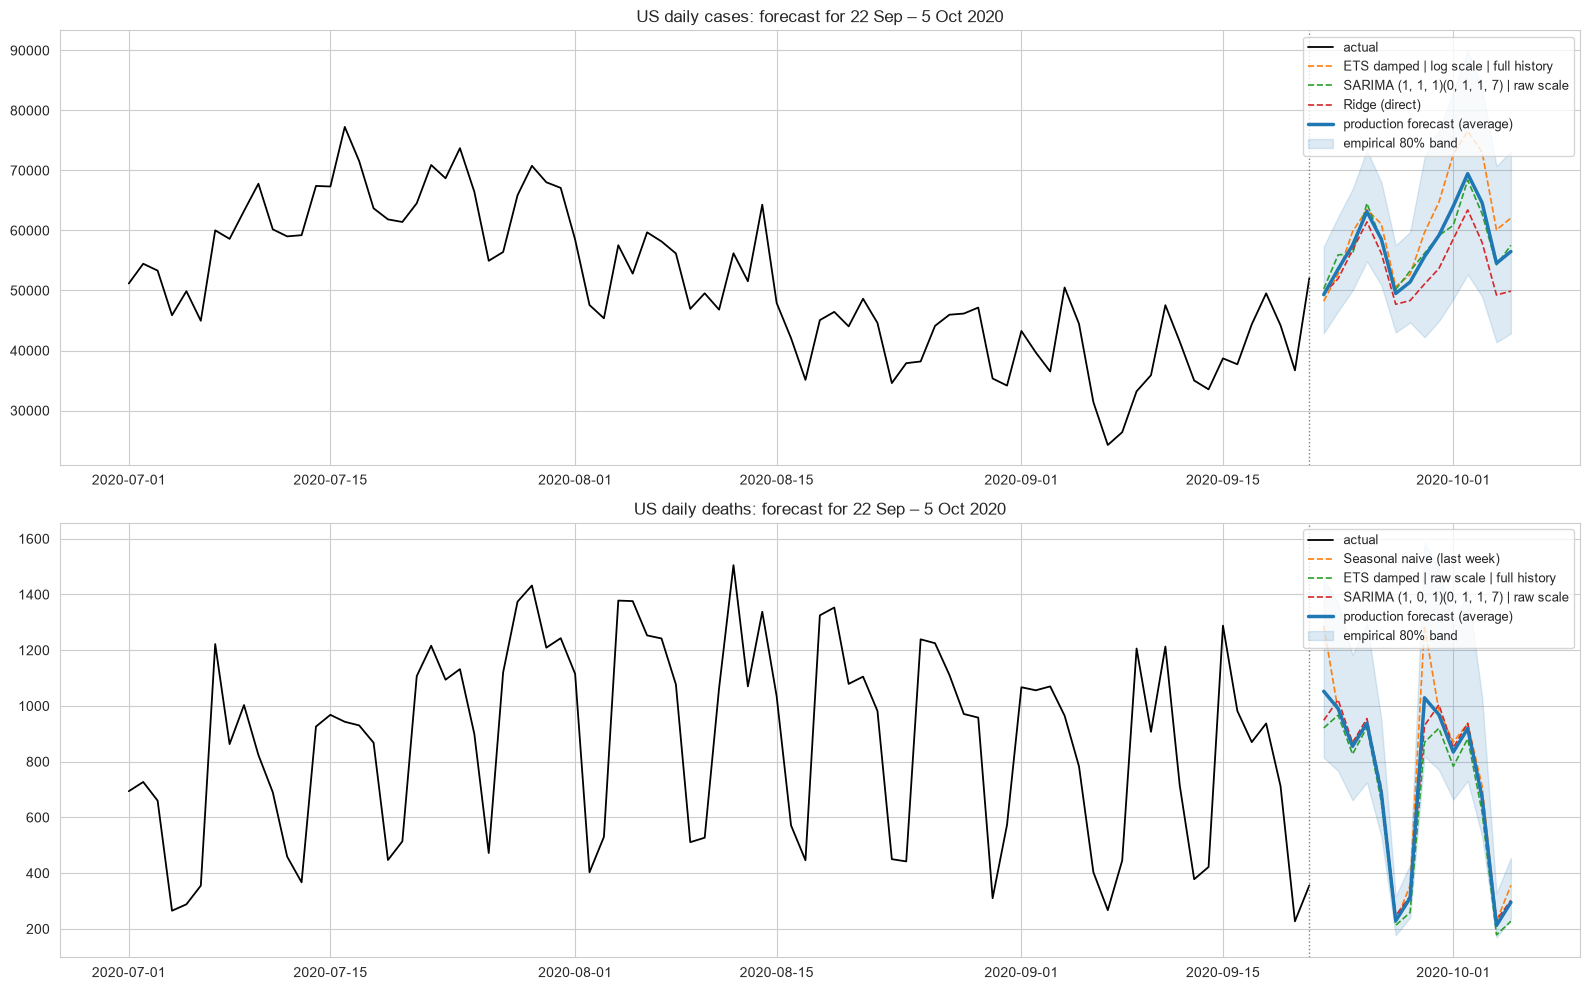

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for ax, target in zip(axes, targets):
    fc = final_forecasts[target]
    ax.plot(us.loc["2020-07-01":, target], color="black", linewidth=1.3, label="actual")
    for k, name in enumerate(combo_members[target]):
        ax.plot(fc.index, fc[name], color=palette[k + 1], linestyle="--", linewidth=1.2, label=name)
    ax.plot(fc.index, fc["forecast"], color=palette[0], linewidth=2.5, label="production forecast (average)")
    ax.fill_between(fc.index, fc["lower_80"], fc["upper_80"], color=palette[0], alpha=0.15,
                    label="empirical 80% band")
    ax.axvline(FINAL_ORIGIN, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"US {target.replace('_', ' ')}: forecast for 22 Sep – 5 Oct 2020")
    ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

The plot shows the forecast in context. For cases, it continues the mid-September upturn and goes above the early-September level, with ETS the steepest member, as it was before. For deaths, it keeps the weekly shape with low Sundays and Mondays and stays around the level of the last few weeks.

### Sensitivity check: how much does 21 Sep matter?
The 21 Sep value could be a genuine jump or a backlog from the weekend. There is no evidence that it is an error, so the production forecast keeps the reported value. To see how much the forecast depends on it, I re-ran the cases combination with 21 Sep replaced by a typical Monday, using the median Monday ratio from the weekday analysis. This is a what-if check only.

In [42]:
# 21 Sep replaced by a typical Monday (median Monday ratio from the weekday analysis) for this check only;
# the production forecast above keeps the reported value
monday_ratio = weekly_eda.loc[weekly_eda["weekday"] == "Monday", "daily_cases_ratio"].median()
other_six_days = last_week["daily_cases"].iloc[:-1].sum()
typical_monday = monday_ratio * other_six_days / (7 - monday_ratio)
print(f"reported 21 Sep: {last_week['daily_cases'].iloc[-1]:,} | typical-Monday value: {typical_monday:,.0f}")

history_adj = us.loc[active_start:FINAL_ORIGIN, "daily_cases"].astype(float).asfreq("D")
history_adj.iloc[-1] = typical_monday
fc_adj = pd.DataFrame({name: np.asarray(test_finalists["daily_cases"][name](history_adj), dtype=float)
                       for name in combo_members["daily_cases"]},
                      index=final_forecasts["daily_cases"].index)
fc_adj["forecast"] = fc_adj.mean(axis=1)

prev_week_total = us.loc[FINAL_ORIGIN - pd.Timedelta(days=13):FINAL_ORIGIN - pd.Timedelta(days=7), "daily_cases"].sum()
fc_main = final_forecasts["daily_cases"]["forecast"]
sensitivity = pd.DataFrame({
    "as reported": [prev_week_total, last_week["daily_cases"].sum(), fc_main.iloc[:7].sum(), fc_main.iloc[7:].sum()],
    "21 Sep as typical Monday": [prev_week_total, other_six_days + typical_monday,
                                 fc_adj["forecast"].iloc[:7].sum(), fc_adj["forecast"].iloc[7:].sum()],
}, index=["8–14 Sep (observed)", "15–21 Sep (observed)", "22–28 Sep (forecast)", "29 Sep–5 Oct (forecast)"])
display(sensitivity.round(0))
pd.DataFrame({"as reported": fc_main, "21 Sep as typical Monday": fc_adj["forecast"]}).round(0)

reported 21 Sep: 52,070 | typical-Monday value: 34,980


,as reported,21 Sep as typical Monday
8–14 Sep (observed),253030.0,253030.0
15–21 Sep (observed),303232.0,286142.0
22–28 Sep (forecast),383044.0,310843.0
29 Sep–5 Oct (forecast),423993.0,319276.0


,as reported,21 Sep as typical Monday
2020-09-22,49322.0,41649.0
2020-09-23,53561.0,43882.0
2020-09-24,57544.0,47700.0
2020-09-25,63144.0,52173.0
2020-09-26,58555.0,47788.0
2020-09-27,49503.0,39402.0
2020-09-28,51416.0,38248.0
2020-09-29,55648.0,42892.0
2020-09-30,59181.0,45135.0
2020-10-01,64046.0,49045.0


Observation: the typical-Monday value is 34,980 instead of 52,070. With it, week 1 becomes 310,843 instead of 383,044 and week 2 becomes 319,276 instead of 423,993, a difference of about 105,000 cases in week 2 from a single day's value. The adjusted path also restores the normal weekly shape, with Monday 28 Sep (38,248) below Sunday 27 Sep (39,402).

Interpretation: the size of the forecast rise depends heavily on one data point, but its direction does not. Both versions forecast continued growth, because cases were already rising before 21 Sep: 8 to 14 Sep had 253,030 cases and 15 to 21 Sep had 286,142 with the adjusted Monday (13% more) or 303,232 as reported (20% more). So the defensible statement is that cases are forecast to keep rising over the next two weeks, by somewhere between about 9% (adjusted) and 26% (as reported) in the first week, and which end is closer will only become clear from the next few days of data.

Limitation: part of the adjusted path lies below the lower edge of the production band (22 Sep: 41,649 against 42,863). The band only captures model error seen in past folds, not uncertainty in the input data, so it understates the real uncertainty when the latest data point is questionable.

### Cumulative confirmed cases and deaths
The brief asks for a forecast of confirmed cases and deaths. The models forecast daily new values, for the reasons given in Section 6, but because the supplied data is cumulative, the forecast can also be stated as cumulative totals. Adding the forecast weekly totals printed above to the last observed cumulative values (US on 21 Sep: 6,856,884 confirmed cases and 199,865 deaths, from the country screening table) gives:

| | 21 Sep (observed) | 28 Sep (forecast) | 5 Oct (forecast) |
|---|---:|---:|---:|
| Cumulative confirmed cases, as reported | 6,856,884 | 7,239,928 | 7,663,921 |
| Cumulative confirmed cases, 21 Sep as typical Monday | 6,856,884 | 7,167,727 | 7,487,003 |
| Cumulative deaths | 199,865 | 204,928 | 209,856 |

So by 5 Oct the US would pass about 7.5 to 7.7 million confirmed cases (9% to 12% more than on 21 Sep) and about 210,000 deaths (5% more). These are simple sums of the daily forecasts, so they carry the same uncertainty and the same dependence on the 21 Sep value. The 80% band is not summed into a cumulative range, because adding daily bounds together would overstate how wide a weekly range really is. The weekly totals were printed as whole numbers, so these figures can differ from an exact sum by a few cases.

## 11. Preparation suggestions for the health department

These are data-informed planning considerations based on the forecast above, from the point of view of 21 Sep 2020. They are not predictions of certain outcomes, and the model is not a substitute for public-health expertise. For each area I separate what the model predicts, what it could mean for planning, and its limits.

### 1. Plan for rising case numbers over the next two weeks, using a range
- **What the model predicts:** confirmed cases rise in both weeks. 22 to 28 Sep: about 311,000 to 383,000 cases (adjusted and as-reported versions). 29 Sep to 5 Oct: about 319,000 to 424,000. The last observed week had 303,232.
- **What it could mean:** testing, laboratory processing and case follow-up (contact tracing, isolation support) could be prepared for a weekly load anywhere from about last week's level to about 40% above it, with the upper end treated as a scenario to be ready for rather than the expected outcome.
- **Limits:** the size of the rise depends heavily on one data point (21 Sep), and across all evaluation folds the week-2 forecasts were off by about 18% on average.

### 2. Expect deaths to stay near the current level within the window, but prepare for a possible rise after it
- **What the model predicts:** about 4,900 to 5,100 deaths per week, similar to or slightly below the last observed week (5,372).
- **What it could mean:** the death models only use past deaths and cannot see the rise in cases. In this data, deaths peaked 10 to 14 days after cases in both waves, and cases started rising in mid-September. If the case rise continues, pressure on hospital and critical care capacity, staffing and supplies could increase from around early October, at the end of or just after this forecast window. Reviewing that capacity now is reasonable even though the 14-day death forecast is flat.
- **Limits:** this point comes from the EDA lag, not from the forecast itself, and it rests on only two waves. The dataset has no hospitalisation figures, so hospital demand cannot be forecast here.

### 3. Read daily numbers with the reporting cycle and holidays in mind
- **What the data shows:** reported cases typically run about 14% below the weekly average on Mondays and 13% above on Fridays, and reported deaths on Sundays are about half the weekly average. The forecast peaks on Fridays (69,460 cases for 2 Oct) and dips on Sundays and Mondays.
- **What it could mean:** decisions should use 7-day totals or averages rather than single days, so a low Monday is not read as improvement. Reporting and laboratory staff could be planned around the mid-to-late-week peaks. Counts around public holidays (Labor Day caused a dip followed by catch-up) need extra care.
- **Limits:** these are reporting patterns in the data. Their causes (laboratory schedules, office hours) are not recorded in it.

### 4. Keep the forecast updated and watch for warning signs
- Re-run the forecast at least weekly. An observed week above the upper edge of the 80% band, or a widening gap between the member forecasts, should trigger a closer review. The models are weakest at turning points, so the next few forecast rounds matter most if the rise continues.
- Check incoming data for incomplete last days and unusual values (as found on 21 Sep for India and the US) before using it.

### 5. Communicate ranges, not single numbers
Internal and public communication could present the forecast as a range with its assumptions, since the next two weeks could reasonably be anywhere from slightly above last week to about 40% higher.

**What these suggestions cannot cover:** the data is a national total, so it says nothing about which states or cities are most affected. It contains no information on testing volumes, hospital occupancy or public-health measures, and it shows associations over time, not causes.

## 12. Challenges report

Each challenge below actually came up in this project. For each one: what the issue was, how it affected the work, how I investigated it, what I did and why, and the result.

### 1. The supplied data differed from the description
**Issue:** the description promised CONVENIENT files with daily changes, US county data and a metadata file. The zip contained only three global files in cumulative form. **Effect:** no daily series was available. **Investigation:** file inventory and the raw first lines of each file. **Technique:** country-level daily values derived by differencing the cumulative totals, followed by two reconciliation checks (last-day totals against the raw rows, and daily sums against final cumulative totals). **Why:** differencing is the simplest transformation that keeps the totals intact, and the checks prove nothing was lost. **Outcome:** both checks passed exactly.

### 2. Inconsistent geography and non-country rows
**Issue:** 7 countries were split into provinces, Canada's recovered data was national while its cases and deaths were provincial, and three cruise ships appeared as countries or provinces. **Effect:** the files could not be joined row by row, and ships would have distorted national totals. **Investigation:** comparing (province, country) keys across files and looking for rows with coordinates (0, 0). **Technique:** aggregation to country level, removal of the ship rows, and leaving recovered out of the modelling. **Why:** the country is the unit being forecast, and ships are not populations. **Outcome:** 186 consistent country series for cases and deaths.

### 3. Revisions and irregular reporting
**Issue:** 31 countries had falls in cumulative cases and 34 in cumulative deaths (the largest −10,034 cases in Spain), and several countries had frequent zero days followed by large catch-up days. **Effect:** negative daily values and batch dumps would be learned as if they were epidemic signal. **Investigation:** counting falls at row and country level, and a screening table with zero-day shares and spike ratios. **Technique:** choosing a country without these problems instead of editing values. **Why:** correcting a revision properly needs to know when the cases actually occurred, which the data doesn't say, so any edit would be guesswork. **Outcome:** the US series needed no corrections, and no value in the data was altered.

### 4. An incomplete final day
**Issue:** India reported 0 cases and 0 deaths on 21 Sep after days with more than 85,000 cases. **Investigation:** locating every zero and negative day for the shortlisted countries and printing their last two weeks. **Technique:** identified as a snapshot taken before India's figures were updated; it would have been dropped had India been chosen, and it supported choosing the US. **Outcome:** no effect on the US models; it became one of the data checks recommended before each production run.

### 5. A strong weekly reporting cycle that changed over time
**Issue:** cases were about 30% higher on Fridays than Mondays, and deaths more than twice as high mid-week as on Sundays. The relative weekly swing in deaths grew from 12% to 36% between April and September. **Effect:** models that ignore the weekday pattern perform badly (naive MAE 413 against 169 for seasonal naive on deaths). **Investigation:** box plots of detrended ratios, ACF after differencing, and the swing-versus-level table. **Technique:** a weekly period in every model (seasonal naive, ETS and SARIMA seasonal terms, weekday features and the same-weekday ratio in the regressions) and a 14-day horizon covering two full weeks. Raw versus log scale and a 56-day training window were tested. **Why:** the pattern was clear in three independent analyses. **Outcome:** the weekly cycle is reproduced in all forecasts. The shorter window did not help, which I report as a tested idea that didn't work.

### 6. Non-stationarity and inconclusive tests
**Issue:** the US series had two waves, declines and an upturn, and the ADF tests gave contradictory results. **Effect:** the amount of differencing could not be decided from the tests, and a single train/test split would have depended heavily on which phase it fell in. **Technique:** comparing d = 0 and d = 1 in SARIMA on validation error, and rolling-origin validation over 8 origins covering rise, peak and decline. **Why:** forecast error is what matters, and unit-root tests are unreliable with regime changes and about 200 observations. **Outcome:** d = 1 worked best for cases and d = 0 slightly better for deaths.

### 7. Risk of temporal leakage
**Issue:** with lag features, rolling statistics and repeated refitting, it is easy to let future values into training. **Technique:** chronological splits only; the evaluator passes each model history truncated at the origin; regression rows are kept only when their target day is observed by the origin; the Ridge scaler is fitted inside the pipeline; centred rolling statistics are used only in the EDA; fold boundaries are checked with assertions; and the production model is selected in code before the holdout is run. **Why:** a leaked forecast looks better than it will be in practice. **Outcome:** the holdout is an honest test, which is why its unflattering result for cases is reported as it is.

### 8. A small effective sample for the machine learning models
**Issue:** each fold had only about 80 to 130 training origins, and the rows from neighbouring origins overlap heavily. **Effect:** Gradient Boosting overfitted the late-June surge and failed badly before the July peak (MAE 21,774 and 17,805). **Technique:** a relative target (each day compared with the current weekly level) so the models don't need to extrapolate, and fixed hyperparameters without tuning. **Why:** tuning on 8 overlapping folds would mostly fit noise. **Outcome:** Ridge was competitive and steady at turning points; Gradient Boosting remained the worst model in validation and is reported as a negative result.

### 9. Turning points and holidays
**Issue:** the trend models failed before the July peak and after Labor Day. **Investigation:** per-fold error tables and the holdout plot. **Technique:** a combination that includes a member that behaves differently at turns (Ridge), plus monitoring recommendations for production. **Why:** with only one holiday in each evaluation window, a holiday effect could not be estimated reliably. **Outcome:** only partly solved. The combination limits the damage but does not remove it, and this is stated as a limitation.

### 10. One influential value at the forecast origin
**Issue:** 21 Sep had 52,070 cases, 1.20 times its week's mean when Mondays are usually around 0.86. **Effect:** it pushed up the whole cases forecast. **Technique:** the reported value was kept, and a sensitivity check replaced it with a typical Monday. **Why:** there is no evidence it is an error, so changing it would not be justified, but planners need to know how much the forecast depends on it. **Outcome:** about 105,000 cases difference in week 2, but the same direction (rising) in both versions.

### 11. Validation and holdout disagreed
**Issue:** the combination was first in validation but fourth on the cases holdout, where Ridge was best. **Technique:** the choice made before the holdout was kept, the reason for the disagreement was traced to the turning point after Labor Day, and monitoring of Ridge on new data was recommended. **Why:** switching models after seeing two test origins would mean selecting on the test set. **Outcome:** the reported holdout errors remain honest estimates.

### Smaller technical issues
pandas 3 reads text columns with a new `str` dtype, a column-wise diff on the wide files raised a fragmentation warning (fixed with `.copy()`), `adfuller` raised a FutureWarning about its return type (fixed with `result_object=False`), and taking logs of the zero counts in January raised a divide-by-zero warning (fixed by masking zeros, which doesn't change any result from April onward).

## 13. Conclusions and limitations

### Conclusions
- **Data:** the supplied data is the JHU global time series (confirmed, deaths, recovered) from 22 Jan to 21 Sep 2020 in cumulative form. Confirmed and deaths were usable after aggregation to country level; recovered was not used for modelling.
- **Country:** the US was the only shortlisted country with no reporting anomalies in either target over its active period, and its several phases made validation meaningful.
- **EDA:** US cases had two waves and were rising again at the end of the data; deaths had a larger first wave and a smaller summer wave. Both have a strong weekly reporting cycle, much stronger for deaths, and deaths peaked 10 to 14 days after cases in both waves.
- **Forecasting setup:** daily cases and deaths, a 14-day horizon, 8 rolling validation origins and a 28-day holdout with 2 origins.
- **Models:** for cases, ETS, SARIMA, Ridge and the combination beat the baselines in validation, while Gradient Boosting did not. For deaths, repeating last week was very hard to beat, and only the combination did so in validation, narrowly.
- **Production model:** the equal-weight average of the top 3 models, chosen on validation before the holdout. It was second on the deaths holdout and fourth on the cases holdout, where Ridge did best. The main weakness of the trend models is turning points, especially with a holiday at the forecast origin.
- **Forecast:** cases are forecast to keep rising in the two weeks after 21 Sep (between about 319,000 and 424,000 in week 2, depending on how the last day is treated). Deaths are forecast to stay roughly flat at about 5,000 a week, with a possible rise just after the window if cases keep increasing. In cumulative terms, that is about 7.5 to 7.7 million confirmed cases and about 210,000 deaths by 5 Oct.

### Limitations
- One country at national level only; differences between states are hidden.
- Confirmed cases depend on testing, which is not in the data.
- Validation covers one summer, and 8 + 2 origins is a small basis for comparing models, especially the 2-origin holdout.
- No information on holidays or interventions; the only outside signal used is lagged case growth in the deaths regressions.
- The 80% band is empirical, based on 10 origins, and does not include uncertainty in the input data.
- All findings are associations over time; nothing here shows what caused the changes in the series.

### Possible next steps
- Re-evaluate the combination weights, particularly Ridge's, on new forecast rounds.
- Add a holiday indicator once the history contains enough holidays to estimate it.
- Use state-level data and testing volumes, if available, to separate detection from spread and make the forecasts more useful locally.